## Import libraries, units dataframe and configure device

In [6]:
import torch
from pathlib import Path
import preprocess_data as ppd
from process_session import session as ps
import numpy as np
from preprocess_data import *
import models as models
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import pandas as pd
import sys
import os
from process_attribution import *
from plots import *
from scipy.sparse import coo_matrix

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'serif']
plt.rcParams['pdf.fonttype'] = 42  # Use TrueType fonts in PDF

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
df = pd.read_csv('tables/units_info.csv')
print(df.head())

      unit_id  session_id                                       genotype  \
0  1179685687  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
1  1179685618  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
2  1179685304  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
3  1179685455  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
4  1179684888  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   

   optotagged  cluster_id  firing_rate  response_mag  sparsity  pyr  sst  ...  \
0           0           0     2.347611     -0.165334 -0.110431    1    0  ...   
1           0           0     0.608558     -0.119121 -0.137173    1    0  ...   
2           0           0     0.932567      0.146078  0.053006    1    0  ...   
3           0           4    11.398961     -0.184356 -0.109291    1    0  ...   
4           0           0     8.338130      0.441873 -0.053603    0    0  ...   

   coher_2_5  coher_5_10  num_conn_e_to_e  num_conn_e_to

## Define session and hyperparameters

In [2]:
# Session obj contains stimulus, channel, and unit information
output_dir  = Path(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022')
session_id  = 1044385384
session_obj = ps(session_id, df, output_dir)
bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
criterion  = torch.nn.MSELoss()
input_size = len(session_obj.units)
num_epochs = 15 # 
batch_size = 32

# hyperparameters
hidden_size = 50 # 
num_layers = 1
seqlength = 750

# define output directory for saved models
output_dir = Path(output_dir)
output_dir_models = output_dir / 'models' / str(session_id)
output_dir_plots = output_dir_models / 'plots'
os.makedirs(output_dir_models, exist_ok=True)
os.makedirs(output_dir_plots, exist_ok=True)


## Get spikes and LFP for active data

In [3]:
# Spikes obj contains Spike matrix
bin_size=0.004
sr = 1/bin_size
spikes_obj = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj.getSpkMat(session_obj.active_times[0], session_obj.active_times[1])
spikes_obj.truncate(seqlength)
# spikes_obj.convolve_with_gaussian() # skip convolution
spikes_obj.minmax()

# Probe obj contains LFP data
# Getting LFP  for active trials
lfp_obj = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.active_times[0],
                              session_obj.active_times[1], output_dir) 
lfp_obj.filter_lfp(take_power = True)
lfp_obj.downsample_lfp(int(1250 /sr)) # Downsample by 5
lfp_obj.truncate(seqlength)
lfp_obj.align_lfp(spikes_obj.spkMat.shape[0])
num_channels = len(lfp_obj.channels)

## Visualize the first 3 seconds of spikes using a heatmap

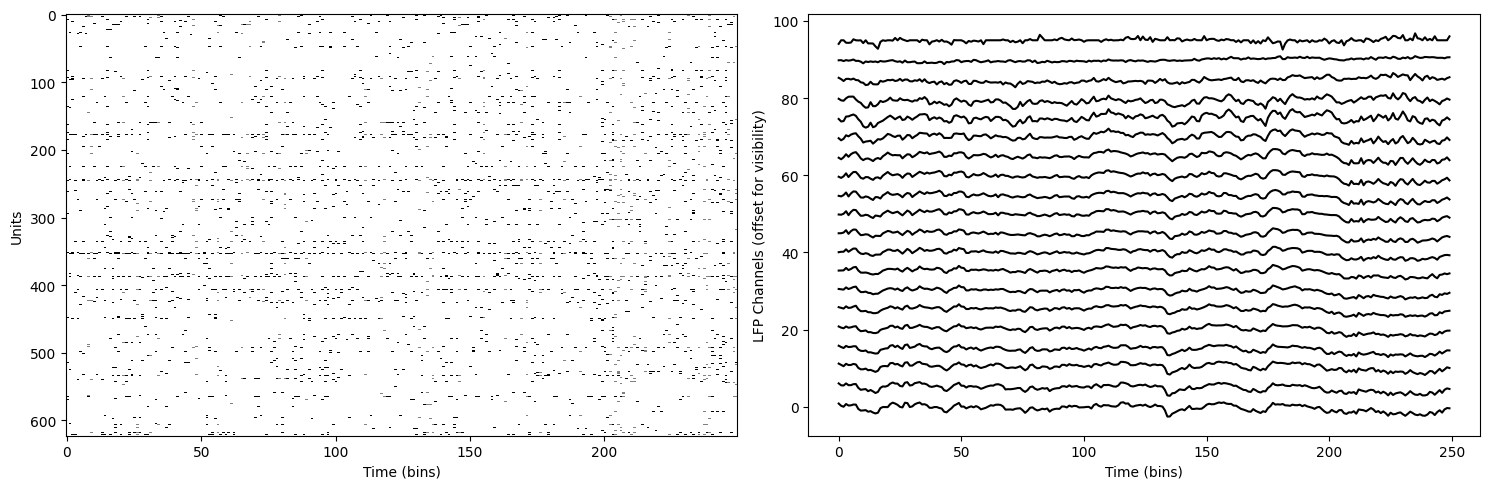

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

ax[0].imshow(spikes_obj.spkMat[:3 * int(sr), :].T * -1 , aspect='auto', cmap='gray', interpolation='none')
# ax[0].colorbar(label='Normalized Spike Rate')
ax[0].set_xlabel('Time (bins)')
ax[0].set_ylabel('Units')

# in the second subplot, plot the broadband LFPs from all channels with a vertical offset
offset = 5
for i in range(num_channels):
    ax[1].plot(lfp_obj.lfpMat[:3 * int(sr), i, 0] + i * offset, color='black')
ax[1].set_xlabel('Time (bins)')
ax[1].set_ylabel('LFP Channels (offset for visibility)')
ax[1].set_xlim(0, 3 * int(sr))
plt.tight_layout()
# plt.savefig(Path(output_dir_plots) / 'spikes_lfp_heatmap.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Get spikes and LFP for spontaneous and passive data

In [58]:
# get spontaneous data
spikes_obj_spont = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj_spont.getSpkMat(session_obj.spontaneous_times[0], session_obj.spontaneous_times[1])
spikes_obj_spont.truncate(seqlength)
# spikes_obj_spont.convolve_with_gaussian()
spikes_obj_spont.minmax()

lfp_obj_spont = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.spontaneous_times[0],
                              session_obj.spontaneous_times[1], output_dir) 
lfp_obj_spont.filter_lfp(take_power = True)
lfp_obj_spont.downsample_lfp(int(1250 /sr)) # Downsample by 5
lfp_obj_spont.truncate(seqlength) # Downsample by 5
lfp_obj_spont.align_lfp(spikes_obj_spont.spkMat.shape[0])

# # get passive data
# spikes_obj_passive = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
# spikes_obj_passive.getSpkMat(session_obj.passive_times[0], session_obj.passive_times[1])
# spikes_obj_passive.truncate(seqlength)
# spikes_obj_passive.convolve_with_gaussian()
# spikes_obj_passive.zscore()

# lfp_obj_passive = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.passive_times[0],
#                                 session_obj.passive_times[1], output_dir)
# lfp_obj_passive.filter_lfp()
# lfp_obj_passive.downsample_lfp(5) # Downsample by 5
# lfp_obj_passive.truncate(seqlength) # Downsample by 5
# lfp_obj_passive.align_lfp(spikes_obj_passive.spkMat.shape[0])

## Compare models on broadband activity from one channel 

In [4]:
chani = 5 # deep layer
bandi = 0 # broadband

X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,chani,bandi], 
                                                      seqlength, prediction_lag=0, test_size=0.2, random_state=42)

train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train, y_test, batch_size)

test_spikes = torch.cat([X for X, _ in test_dataloader], dim=0)
test_lfp = torch.cat([y for _, y in test_dataloader], dim=0)

# reshape to time X features
test_spikes = test_spikes.reshape(test_spikes.shape[0] * test_spikes.shape[1], test_spikes.shape[2])
test_lfp = test_lfp.reshape(test_lfp.shape[0] * test_lfp.shape[1])

## Linear regression model 

Linear regression train loss: 0.7525
Linear regression test loss: 0.7694


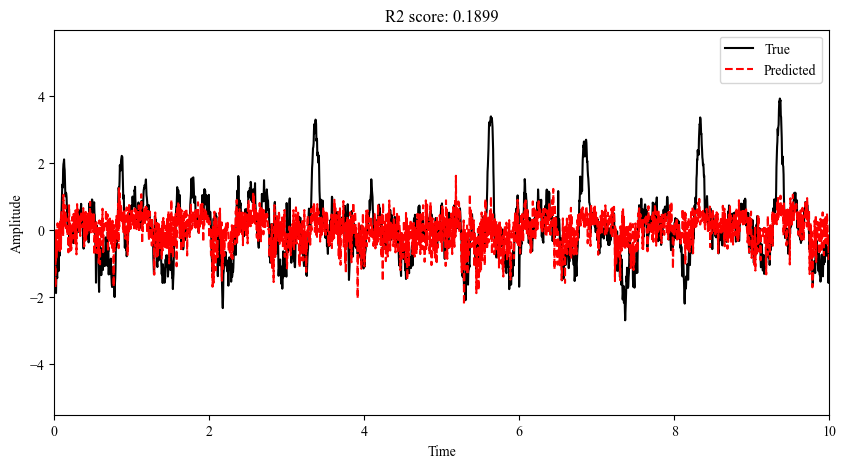

In [8]:
linear_model = models.LinearRegressionModel(input_size)
ln_train_loss, ln_test_loss = linear_model.train(train_dataloader,
                                               test_dataloader, numepochs=1)

print(f'Linear regression train loss: {ln_train_loss[-1]:.4f}')
print(f'Linear regression test loss: {ln_test_loss[-1]:.4f}')

# Evaluate the linear model
y_hat_test = linear_model.evaluate(test_spikes)

time_test = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time_test, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time_test, y_hat_test, '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test):.4f}')
ax.legend()

# save figure in pdf format
plt.savefig(output_dir_plots / 'linear_model_active.pdf', format='pdf', dpi=300, bbox_inches='tight')

plt.show()


y_hat_spont = linear_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float())

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont, '--r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont):.4f}')
ax.legend()

# save figure in pdf format
plt.savefig(output_dir_plots / 'linear_model_spont.pdf', format='pdf', dpi=300, bbox_inches='tight')

plt.show()

## GRU model

In [ ]:
gru_model = models.process_model(models.GRUnet(input_size, hidden_size, num_layers,seqlength, batchNorm=False), criterion, device)
gru_train_loss, gru_test_loss = gru_model.train(train_dataloader,
                                        test_dataloader , num_epochs)

total_params = sum(p.numel() for p in gru_model.model.parameters())
print(f"Total parameters: {total_params:,}")
print(f'GRU  train loss: {gru_train_loss[-1]:.4f}')
print(f'GRU  test loss: {gru_test_loss[-1]:.4f}')

y_hat_test = gru_model.evaluate(test_dataloader.dataset.tensors[0])

time = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time, y_hat_test.cpu().numpy(), '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test.cpu().numpy()):.4f}')
ax.legend()
# save figure in pdf format
plt.savefig(output_dir_plots / 'GRU_model_active.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

y_hat_spont = gru_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float().to(device))

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont.cpu().numpy(), '--r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont.cpu().numpy()):.4f}')
ax.legend()
# save figure in pdf format
plt.savefig(output_dir_plots / 'GRU_model_spont.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

Total parameters: 102,547
GRU  train loss: 0.1361
GRU  test loss: 0.1345


## LSTM model

Total parameters: 116,627
LSTM  train loss: 0.2323
LSTM  test loss: 0.2811


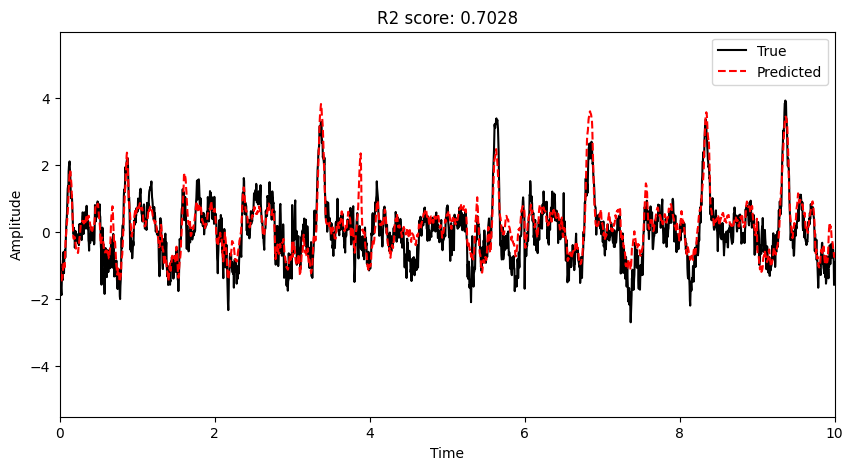

In [ ]:
lstm_model = models.process_model(models.LSTMnet(input_size, hidden_size, num_layers,seqlength, 
                                                 conv=True,kernel_size=5, out_channels=32 ,batchNorm=False), criterion, device)
lstm_train_loss, lstm_test_loss = lstm_model.train(train_dataloader,
                                        test_dataloader , num_epochs)

total_params = sum(p.numel() for p in lstm_model.model.parameters())
print(f"Total parameters: {total_params:,}")
print(f'LSTM  train loss: {lstm_train_loss[-1]:.4f}')
print(f'LSTM  test loss: {lstm_test_loss[-1]:.4f}')

y_hat_test = lstm_model.evaluate(test_dataloader.dataset.tensors[0])

time = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time, y_hat_test.cpu().numpy(), '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test.cpu().numpy()):.4f}')
ax.legend()
# save figure in pdf format
plt.savefig(output_dir_plots / 'LSTM_model_active.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

y_hat_spont = lstm_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float().to(device))

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont.cpu().numpy(), '--r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont.cpu().numpy()):.4f}')
ax.legend()
# save figure in pdf format
plt.savefig(output_dir_plots / 'LSTM_model_spont.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show() 

## 5 Hz oscillation example 

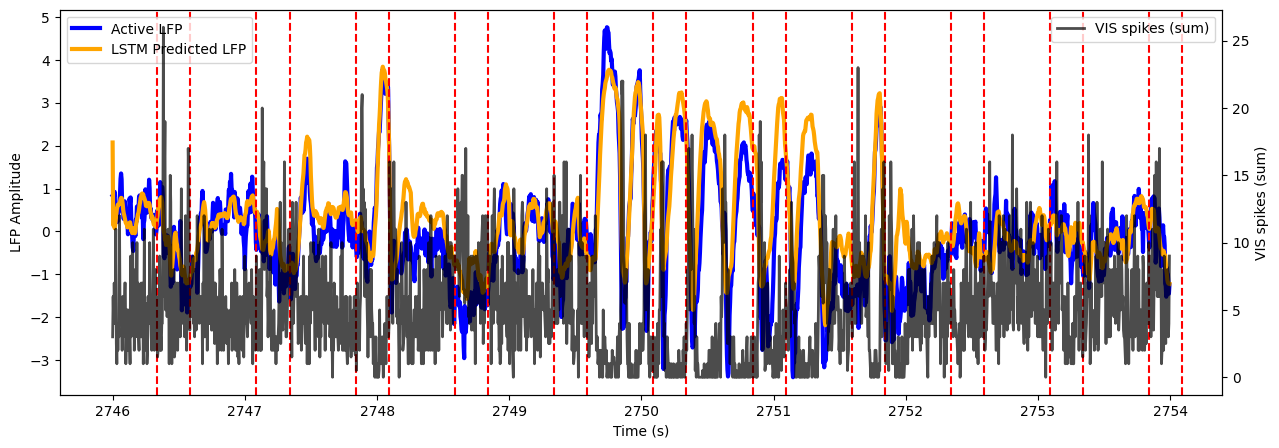

In [ ]:
timestamps = spikes_obj.timestamps
y_hat = lstm_model.evaluate(torch.tensor(spikes_obj.spkMat).float().to(device)).cpu().detach().numpy()

stim_st = session_obj.stimulus_presentation.start_time
stim_st = stim_st.values

tp = 2750 # time point to plot in seconds
tidx1 = np.argmin(np.abs(timestamps - tp))
win_sec  = 4
win_bins = int(win_sec * sr)
# find stimuli times around tp
stim_st_near_tp  = stim_st[(stim_st >= (tp - win_sec)) & (stim_st <= (tp + win_sec))]

fig, ax = plt.subplots(figsize=(15,5))
ax.plot(timestamps[tidx1-win_bins:tidx1+win_bins], 
        lfp_obj.lfpMat[tidx1-win_bins:tidx1+win_bins, 5, 0], label='Active LFP', color='black', linewidth=3)
ax.plot(timestamps[tidx1-win_bins:tidx1+win_bins], 
        y_hat[tidx1-win_bins:tidx1+win_bins], label='LSTM Predicted LFP', color='red', linewidth=3)

# create a second y-axis correctly and plot aggregated VIS spikes
ax2 = ax.twinx()
# sum VIS-unit spike counts across neurons to get a single time series for plotting
spikes_vis = spikes_obj.spkMat[tidx1-win_bins:tidx1+win_bins, 
                               spikes_obj.units['structure_acronym'].str.contains('VIS')].sum(axis=1)
ax2.plot(timestamps[tidx1-win_bins:tidx1+win_bins], 
         spikes_vis, label='VIS spikes (sum)', color='black', alpha=.5, linewidth=2)
ax2.set_ylabel('VIS spikes (sum)')

# add dashed lines for stimulus times
for s in stim_st_near_tp:
    ax.axvline(x=s, color='red', linestyle='--', alpha=1)
    ax.axvline(x=s+0.25, color='red', linestyle='--', alpha=1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('LFP Amplitude')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

## Transformer model

In [ ]:
num_epochs_transformer = 10
transformer_model = models.process_model(models.SpikingTransformer(input_size=input_size, seqlength=50,
                                                                   embedding_dim = 32,
                                                                   num_heads = 2, 
                                                                   num_layers = 2, use_conv=True, conv_kernel_size=3,
                                                                   conv_out_channels=64,
                                                                   dropout=0.1), criterion, device)

X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,chani,bandi], 
                                                    50, prediction_lag=0, test_size=0.2, random_state=42)

train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train, y_test, batch_size)

transformer_train_loss, transformer_test_loss = transformer_model.train(train_dataloader,
                                        test_dataloader , num_epochs_transformer, lr = 0.0004, weight_decay= 6.7e-06)

print(f'transformer  train loss: {transformer_train_loss[-1]:.4f}')
print(f'transformer  test loss:  {transformer_test_loss[-1]:.4f}')

y_hat_test = transformer_model.evaluate(test_spikes)

time = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time, y_hat_test.cpu().numpy(), '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test.cpu().numpy()):.4f}')
ax.legend()
# save figure in pdf format 
plt.savefig(output_dir_plots / 'Transformer_model_active.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

y_hat_spont = transformer_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float())

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont.cpu().numpy(), '--r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont.cpu().numpy()):.4f}')
ax.legend()
# save figure in pdf format 
plt.savefig(output_dir_plots / 'Transformer_model_spont.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

transformer  train loss: 0.1229
transformer  test loss:  0.1267


## Investigate the hidden states of the LSTM model

In [ ]:
# Initialize hidden state
h = torch.zeros(num_layers, 1, hidden_size).to(device)
c = torch.zeros(num_layers, 1, hidden_size).to(device)

hidden_states = []
cell_states = []

with torch.no_grad():
    for i in range(test_spikes.shape[0]):
        x = test_spikes[i].unsqueeze(0).unsqueeze(0).to(device)
        output, (h, c) = lstm_model.model.lstm(x, (h, c))
        hidden_states.append(h.squeeze(0).cpu().numpy())
        cell_states.append(c.squeeze(0).cpu().numpy())
        
hidden_states = np.array(hidden_states)
cell_states = np.array(cell_states)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(hidden_states[:1000,0, 0], 'r', label='Hidden state 0')
ax.plot(cell_states[:1000,0, 0], 'b', label='Cell state 0')
ax.plot(test_lfp[:1000].cpu().numpy(), 'k', label='LFP')
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title('Hidden state 0 and LFP')
plt.legend()
plt.show()

# do pca on hidden and cell states
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
pca.fit(hidden_states.reshape(-1, hidden_states.shape[-1]))
pca_hidden = pca.transform(hidden_states.reshape(-1, hidden_states.shape[-1]))

plt.plot(pca.explained_variance_ratio_, 'ko-')
plt.xlabel('Principal component')
plt.ylabel('Variance explained')
plt.title('PCA on hidden states')
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(pca_hidden[:1000,0], 'r', label='Hidden state 0')
ax.plot(pca_hidden[:1000,1], 'b', label='Hidden state 1')
ax.plot(pca_hidden[:1000,2], 'g', label='Hidden state 2')
ax.plot(test_lfp[:1000].cpu().numpy(), 'k', label='LFP')
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title('PCA of hidden states and LFP')
plt.legend()
plt.show()


## Run the LSTM model on all channels and bands

In [6]:
lossesTrain, lossesTest = (np.zeros((len(lfp_obj.channels), num_epochs, len(bands)+1)) for _ in range(2))
R2_train, R2_test       = (np.zeros((len(lfp_obj.channels), len(bands)+1)) for _ in range(2))

# initialize dictionary to store trained models 
all_models = {}

for bandi in range(len(bands)+1):
    sys.stdout.write('\r' + 'Working on band ' + str(bandi + 1) + ' out of ' + str(len(bands)+1) + '\n')
    
    X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,:,bandi], 
                                                      seqlength, test_size=0.2, random_state=42)

    for chani in range(len(lfp_obj.channels)):
        sys.stdout.write('\t' + 'Training model for channel ' + str(chani+1) + ' out of ' + str(lfp_obj.lfpMat.shape[1]) + '\n')
        
        train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train[:,:,chani], y_test[:,:,chani], batch_size)
        
        model = models.process_model(models.LSTMnet(input_size, hidden_size, num_layers,seqlength, 
                                                 conv=True,kernel_size=5, out_channels=32 ,batchNorm=False), criterion, device)
        
        train_loss, test_loss = model.train(train_dataloader,
                                        test_dataloader , num_epochs)
        
        yHat = model.evaluate(test_dataloader.dataset.tensors[0]).cpu().numpy()
        R2_test[chani, bandi] = r2_score(test_dataloader.dataset.tensors[1].cpu().numpy().reshape(-1,1), yHat)
        yHat = model.evaluate(train_dataloader.dataset.tensors[0]).cpu().numpy()
        R2_train[chani, bandi] = r2_score(train_dataloader.dataset.tensors[1].cpu().numpy().reshape(-1,1), yHat)
        
        lossesTrain[chani,:, bandi] = train_loss
        lossesTest[chani,:, bandi] = test_loss
        
        all_models[chani, bandi] = model


Working on band 1 out of 9
	Training model for channel 1 out of 20
	Training model for channel 2 out of 20
	Training model for channel 3 out of 20
	Training model for channel 4 out of 20
	Training model for channel 5 out of 20
	Training model for channel 6 out of 20
	Training model for channel 7 out of 20
	Training model for channel 8 out of 20
	Training model for channel 9 out of 20
	Training model for channel 10 out of 20
	Training model for channel 11 out of 20
	Training model for channel 12 out of 20
	Training model for channel 13 out of 20
	Training model for channel 14 out of 20
	Training model for channel 15 out of 20
	Training model for channel 16 out of 20
	Training model for channel 17 out of 20
	Training model for channel 18 out of 20
	Training model for channel 19 out of 20
	Training model for channel 20 out of 20
Working on band 2 out of 9
	Training model for channel 1 out of 20
	Training model for channel 2 out of 20
	Training model for channel 3 out of 20
	Training model

## get model predictions for the entire active session

In [ ]:
yHat_active = np.zeros((lfp_obj.lfpMat.shape[0], lfp_obj.lfpMat.shape[1], len(bands)+1))
for chani in range(len(lfp_obj.channels)):
    for bandi in range(len(bands)+1):
        prediction = all_models[chani, bandi].evaluate(torch.tensor(spikes_obj.spkMat).float().to(device))
        yHat_active[:,chani,bandi] = prediction.cpu().detach().numpy()

## Plot model results

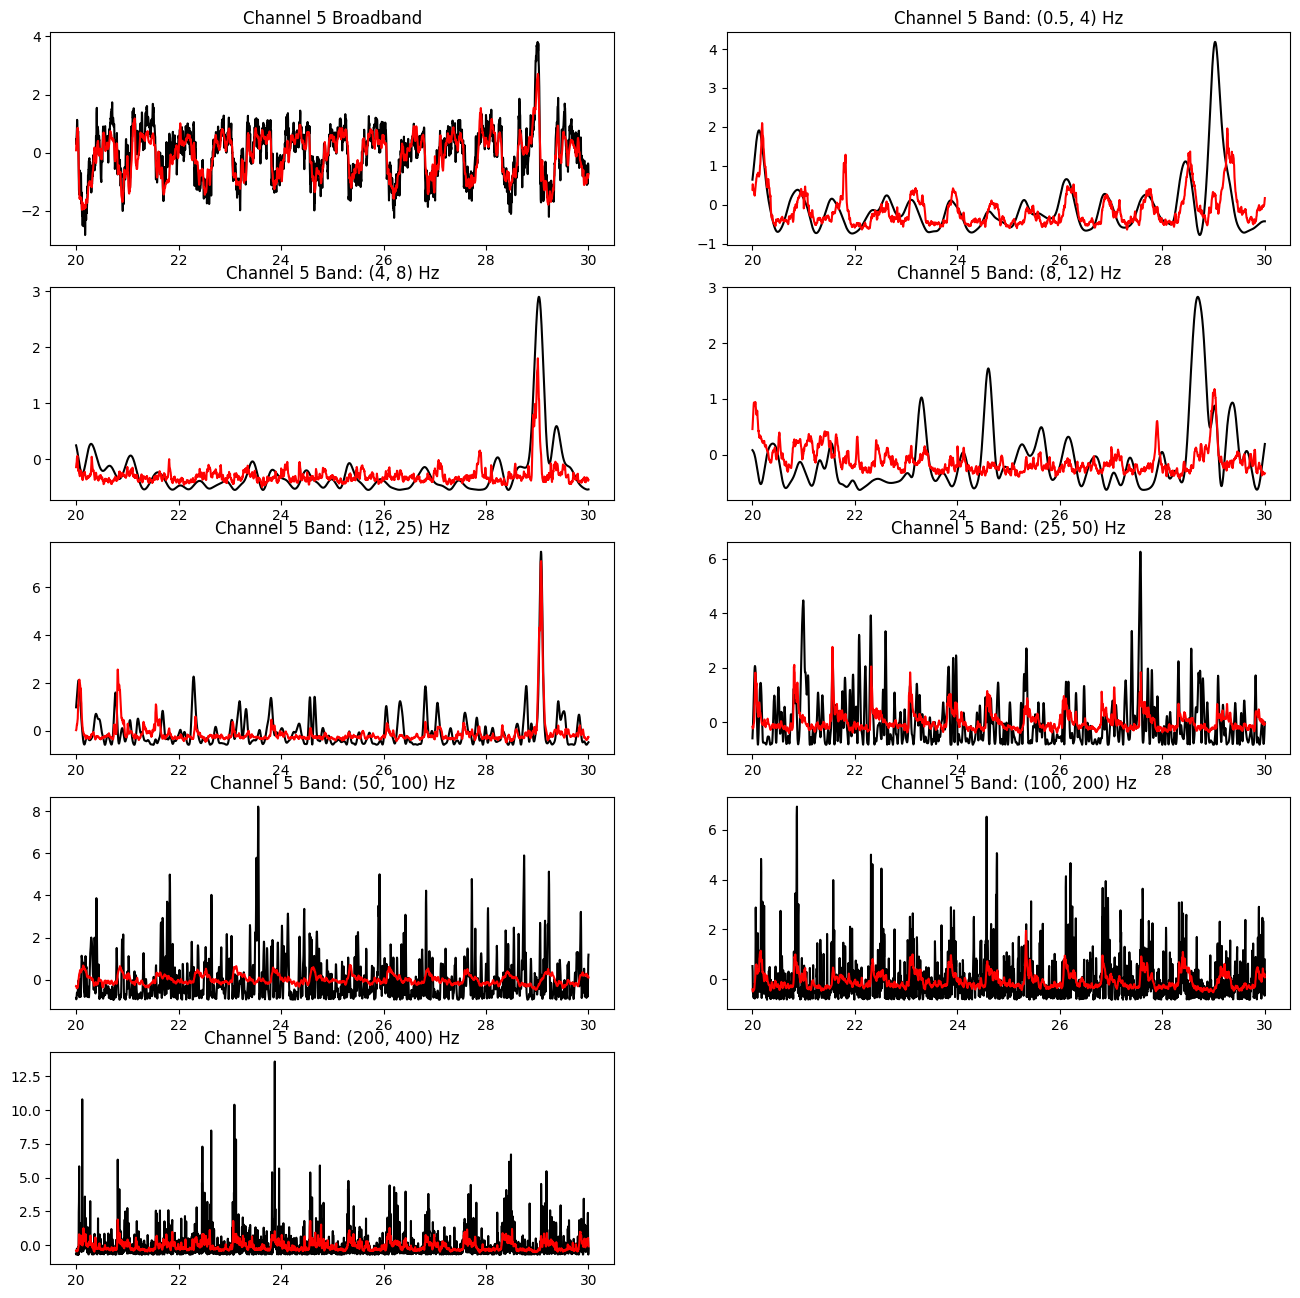

In [ ]:
plot_r2(R2_test, lfp_obj.channels, bands)
plot_all_channel_loss(lfp_obj.channels, bands, 0, lossesTest)
plot_lfp_prediction(lfp_obj.lfpMat, yHat_active, 5, bands, start_time = 20, end_time = 30, save_fig=True, output_dir=output_dir_plots)
plot_abs_error_change(lfp_obj.lfpMat, yHat_active, session_obj, spikes_obj.timestamps, 5, bands)
plot_psd(lfp_obj.lfpMat, yHat_active, 5)

## Save the models 

In [ ]:
for idx in range(len(all_models.keys())):
    chan = list(all_models.keys())[idx][0]
    band = list(all_models.keys())[idx][1]
    filename = output_dir_models / f'lstm_model_chan{chan}_band{band}.pt'
    torch.save(all_models[chan, band].model.state_dict(), filename)

## Load the models if not in memory

In [ ]:
if 'all_models' not in locals():
    all_models = {}
    for chan in range(num_channels):
        for band in range(len(bands)+1):
            filename = output_dir_models / f'lstm_model_chan{chan}_band{band}.pt'
            model = models.process_model(models.LSTMnet(input_size, hidden_size, num_layers,seqlength, 
                                                 conv=True,kernel_size=5, out_channels=32 ,batchNorm=False), criterion, device)
            model.model.load_state_dict(torch.load(filename))
            all_models[chan, band] = model
print('Models loaded from disk')

Models loaded from disk


## Run attribution analysis using integrated gradients

In [ ]:
os.makedirs(output_dir_models / 'attrs' , exist_ok=True)
from IntegratedGradient import IntegratedGradient
import tqdm

attr_dur = 720
X_attr = torch.tensor(spikes_obj.spkMat[:int(attr_dur/bin_size),:]).float().to(device)
num_trials = int(int(attr_dur/bin_size)/seqlength)
X_attr = X_attr.reshape(num_trials, seqlength, X_attr.shape[1])
mean_attribution = np.zeros((num_channels, len(bands)+1 , spikes_obj.spkMat.shape[1]))

for chani in range(num_channels):
    for bandi in range(len(bands)+1):
        model = all_models[chani, bandi]
        ig = IntegratedGradient(model.model.train().to(device), method='last time point')        
        attrs = np.zeros((num_trials, seqlength, input_size))
        for trl in tqdm.tqdm(range(num_trials)):
            attr = ig.attribute(X_attr[trl], baselines = 0, n_steps = 50)[0].squeeze(0).cpu().numpy()
            attrs[trl,:,:] = attr
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        # save the attribution scores for each channel and band    
        attrs = attrs.reshape(num_trials * seqlength, input_size)
        filename = output_dir_models / 'attrs' / f'attribution_scores_chan{chani}_band{bandi}.npy'
        mean_attribution[chani, bandi, :] = np.mean(attrs, axis=0)
        np.save(filename, attrs.astype('float32'), allow_pickle=True)

## In case the above loop was interrupted calculate the mean attribution scores across all channels and bands 

In [ ]:
# mean_attribution = np.zeros((num_channels, len(bands)+1 , spikes_obj.spkMat.shape[1]))
# for chani in range(num_channels):
#     for bandi in range(len(bands)+1):
#         filename = output_dir_models / 'attrs' / f'attribution_scores_chan{chani}_band{bandi}.npy'
#         attrs = np.load(filename, allow_pickle=True)
#         mean_attribution[chani, bandi, :] = np.mean(attrs, axis=0)

## Calculate the mean attribution for th edifferent areas and clusters

In [ ]:
# for each area, calculate the mean attribution across all channels and bands
areas = sorted(session_obj.units['structure_acronym'].unique())
attributions_areas = np.zeros((len(areas), len(bands)+1, num_channels))
for areai, area in enumerate(areas):
    ind = ([session_obj.units['structure_acronym'] == area])[0]
    for chani in range(num_channels):
        for bandi in range(len(bands)+1):
            attributions_areas[areai, bandi, chani] = np.mean(mean_attribution[chani, bandi, ind])
            
# for each cluster, calculate the mean attribution across all channels and bands            
cluster_id = {1:[], 2:[], 3:[], 4:[], 5:[]}
for i in range(1,6):
    cluster_id[i] = list(df.unit_id[df['cluster_id'] == i])
    
mean_attr_clusters = np.zeros((len(df['cluster_id'].unique()), len(bands)+1, num_channels))

for clusteri in range(1,6):
    for bandi in range(len(bands)+1):
        for chani in range(num_channels):
            ind = session_obj.units.index.isin(cluster_id[clusteri])
            mean_attr_clusters[clusteri, bandi, chani] = np.mean(mean_attribution[chani, bandi, ind])

## Plot the attribution results 

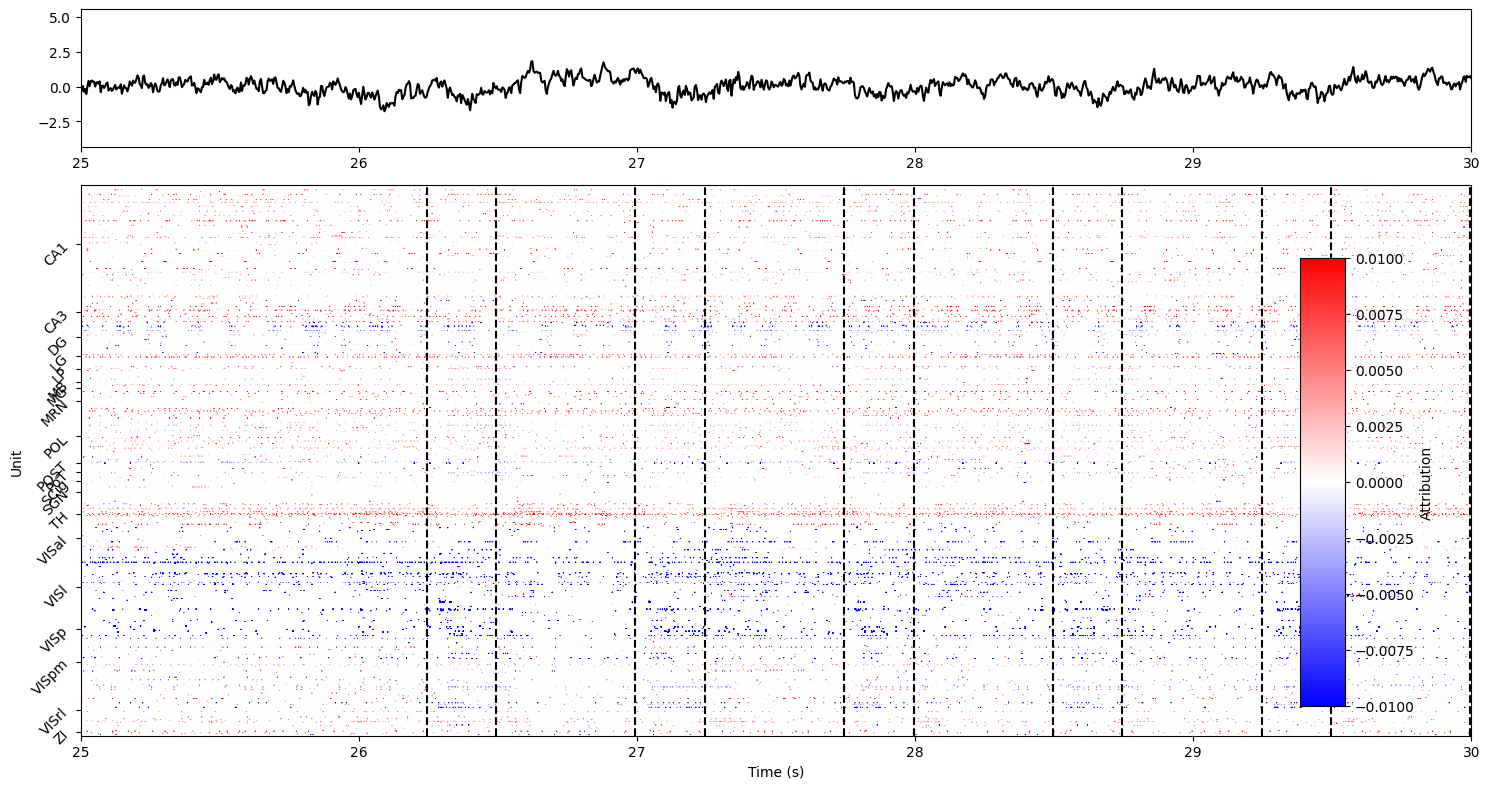

In [ ]:
plot_attr_density_plots(mean_attribution, session_obj, bands, 'VIS')
plot_mean_attr_areas(attributions_areas, lfp_obj, session_obj, bands)
plot_mean_attr_pyr_int(mean_attribution, session_obj, 'VIS', df, bands, 5)
plot_mean_attr_clusters(mean_attr_clusters, lfp_obj , bands)

chani = 5
broadband_attr = np.load(output_dir_models / 'attrs' / f'attribution_scores_chan{chani}_band{0}.npy')

plot_attr_corrmat(broadband_attr,session_obj)
plot_attr_matrix(broadband_attr,lfp_obj.lfpMat[:int(attr_dur/bin_size),6,0], spikes_obj.timestamps[:int(attr_dur/bin_size)], 
                 session_obj, [spikes_obj.timestamps[0], spikes_obj.timestamps[0]+5], plot_stim = True)

plot_attr_lfp_corr(broadband_attr, lfp_obj.lfpMat[:int(attr_dur/bin_size),chani,0], session_obj) # max sorting
plot_attr_lfp_corr(broadband_attr, lfp_obj.lfpMat[:int(attr_dur/bin_size),chani,0], session_obj, sorting = "areas") # areas


## Compare the attribution of active period with the spontaneous period

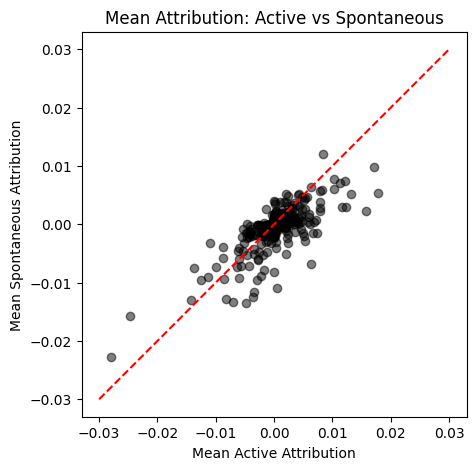

In [ ]:
# import min max scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
broadband_attr = np.load(output_dir_models / 'attrs' / f'attribution_scores_chan{5}_band{0}.npy')
relative_attr = broadband_attr / np.sum(np.abs(broadband_attr), axis=1, keepdims=True)
mean_active_attr = np.nanmean(relative_attr, axis=0)
mean_spontaneous_attr = np.load(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\avr_attrs\1044385384_attribution_scores_spontaneous_mean.npy')
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
# ax.scatter(scaler.fit_transform(mean_active_attr.reshape(-1, 1)), scaler.fit_transform(mean_spontaneous_attr[5,0,:].reshape(-1, 1)), c='k', alpha=0.5)
ax.scatter(mean_active_attr, mean_spontaneous_attr[5,0,:], c='k', alpha=0.5)
ax.set_xlabel('Mean Active Attribution')
ax.set_ylabel('Mean Spontaneous Attribution')
ax.set_title('Mean Attribution: Active vs Spontaneous')
ax.plot([-0.03, 0.03], [-0.03, 0.03], 'r--')
ax.set_aspect(1.0/ax.get_data_ratio(), adjustable='box')
plt.savefig(output_dir_plots / 'active_vs_spontaneous_attr.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [53]:
output_dir = Path(output_dir)
output_dir_models = output_dir / 'models' / str(session_id)
broadband_attr = np.load(output_dir_models / 'attrs' / f'attribution_scores_chan{5}_band{0}.npy')
max_neuron = np.argmax(np.mean(np.abs(broadband_attr),axis=0)) 
print(f'Max neuron in channel 5: {max_neuron}')

Max neuron in channel 5: 216


In [ ]:
attr_dur = 720
mean_snippet_allchan     = np.zeros((num_channels, 188, spikes_obj.spkMat.shape[1]))
mean_lfp_snippet_allchan = np.zeros((num_channels, 188))
neuron_channel_corr      = np.zeros((num_channels, spikes_obj.spkMat.shape[1]))

# plot_unit_attr_fr_corr(unit_attr_fr_corr, session_obj, bands)
for chani in range(num_channels):
    broadband_attr = np.load(output_dir_models / 'attrs' / f'attribution_scores_chan{chani}_band{0}.npy')
    attr_snippets, lfp_snippets, t = plot_peri_stim_attr(broadband_attr, lfp_obj.lfpMat[:int(attr_dur/bin_size),chani,0], session_obj,
                        spikes_obj.timestamps[:int(attr_dur/bin_size)], [-.25, 0.5], show_plot=False)
    mean_snippets = np.mean(attr_snippets, axis=0)
    mean_lfp_snippet_allchan[chani,:] = np.mean(lfp_snippets, axis=0)
    mean_snippet_allchan[chani,:,:] = mean_snippets
    for uniti in range(spikes_obj.spkMat.shape[1]):
        corr = np.corrcoef(broadband_attr[:,uniti], spikes_obj.spkMat[:int(attr_dur/bin_size),uniti])[0,1]
        neuron_channel_corr[chani, uniti] = corr


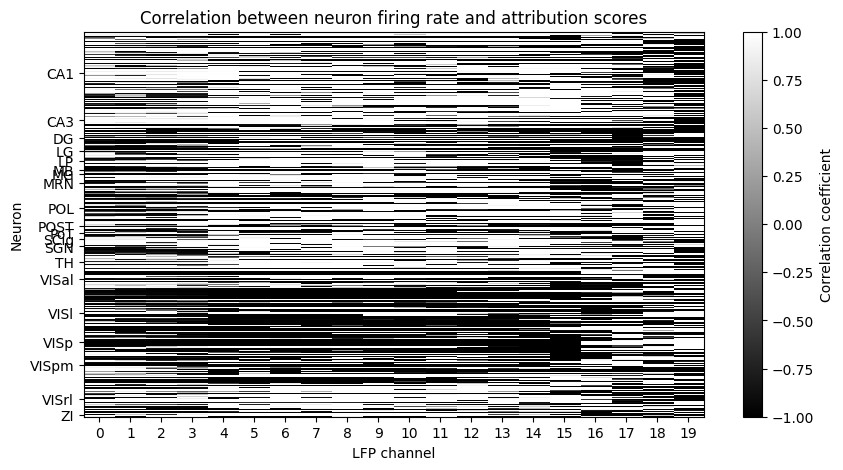

In [55]:
locs = session_obj.units['structure_acronym']
sidx = np.argsort(locs.values)
sorted_locs = locs.values[sidx]

# for each area, find the first and last unit
areas = np.unique(sorted_locs)
first = []
last  = []
for area in areas:
    ind = sorted_locs == area
    first.append(np.where(ind)[0][0])
    last.append(np.where(ind)[0][-1])
middle = (np.array(first) + (np.array(last) - np.array(first)) / 2).astype(int)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.imshow(neuron_channel_corr[:,sidx].T, aspect='auto', cmap='gray', vmin=-1, vmax=1, interpolation='none')
ax.set_xlabel('LFP channel')
ax.set_ylabel('Neuron')
ax.set_title('Correlation between neuron firing rate and attribution scores')
ax.set_xticks(np.arange(num_channels))
ax.set_yticks(middle)
ax.set_yticklabels(areas)
cbar = plt.colorbar(mappable=ax.images[0], ax=ax)
cbar.set_label('Correlation coefficient')
plt.show()

In [94]:
# calculate the CSD of the LFP snippets
timestamps = spikes_obj.timestamps[:int(attr_dur/bin_size)]
stim_st = session_obj.stimulus_presentation.start_time
stim_st = stim_st[((stim_st - np.abs(t[0])) > timestamps[0]) & ((stim_st + np.abs(t[-1])) < timestamps[-1])]
stim_st = stim_st.values

csd = np.diff(np.diff(lfp_obj.lfpMat[:int(attr_dur/bin_size),:,0], axis=1), axis=1)
csd_snippets = np.zeros((csd.shape[1], 188))
for i in range(len(stim_st)):
    start = np.argmin(np.abs(timestamps - (stim_st[i]- np.abs(t[0])  )))
    csd_snippets += csd[start:start+len(t),:].T
csd_snippets /= len(stim_st)

# calculate the PSTHs of all neurons
psth = np.zeros((spikes_obj.spkMat.shape[1], 188))
for i in range(len(stim_st)):
    start = np.argmin(np.abs(timestamps - (stim_st[i]- np.abs(t[0])  )))
    psth += spikes_obj.spkMat[start:start+len(t),:].T
psth /= len(stim_st)

In [138]:
# find the 10 neurons with highest mean absolute attribution in channel 5 broadband
mean_abs_attribution = np.mean(np.abs(broadband_attr), axis=0)
top_neurons = np.argsort(mean_abs_attribution)[-10:]
print(f'Top 10 neurons with highest mean absolute attribution in channel 5 broadband: {top_neurons}')

Top 10 neurons with highest mean absolute attribution in channel 5 broadband: [479 564 383 311 387 352 100 195 271 353]


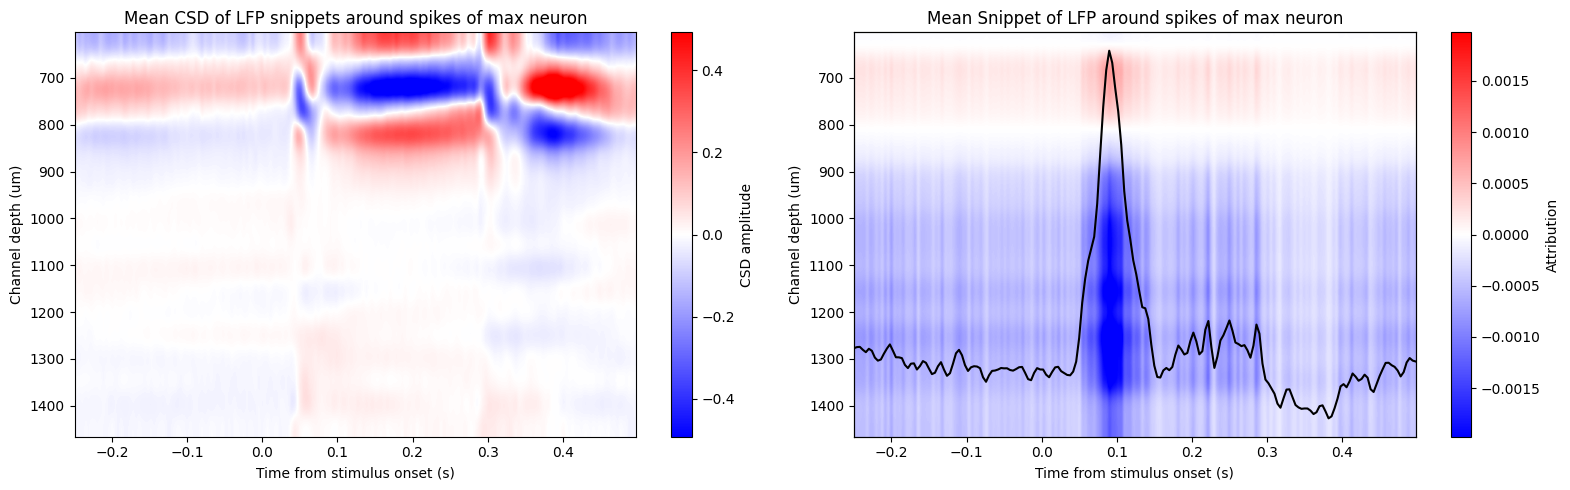

In [242]:
# plot mean_snippet_allchan for unit 18 and the CSD
from scipy.ndimage import gaussian_filter

celli = 18  
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
im = ax[0].imshow(csd_snippets, aspect='auto', cmap='bwr', interpolation='gaussian',
                vmin=-np.max(np.abs(csd_snippets))/2, vmax=np.max(np.abs(csd_snippets))/2,
                extent = [t[0], t[-1], 
                   lfp_obj.channels['dorsal_ventral_ccf_coordinate'].iloc[-1], 
                   lfp_obj.channels['dorsal_ventral_ccf_coordinate'].iloc[1]])
ax[0].invert_yaxis()
ax[0].set_xlabel('Time from stimulus onset (s)')
ax[0].set_ylabel('Channel depth (um)')
ax[0].set_title('Mean CSD of LFP snippets around spikes of max neuron')
plt.colorbar(im, ax=ax[0], label='CSD amplitude')

im = ax[1].imshow(mean_snippet_allchan[1:-1,:,celli], aspect='auto', cmap='bwr', interpolation='gaussian', 
           vmin=-np.max(np.abs(mean_snippet_allchan[:,:,celli]))/1.5, 
           vmax=np.max(np.abs(mean_snippet_allchan[:,:,celli]))/1.5,
           extent=[t[0], t[-1], 
                   lfp_obj.channels['dorsal_ventral_ccf_coordinate'].iloc[-1], 
                   lfp_obj.channels['dorsal_ventral_ccf_coordinate'].iloc[1]])
ax[1].invert_yaxis()
ax[1].set_xlabel('Time from stimulus onset (s)')
ax[1].set_ylabel('Channel depth (um)')
ax[1].set_title('Mean Snippet of LFP around spikes of max neuron')
plt.colorbar(im, ax=ax[1], label='Attribution')
# overlay the neuron's psth on top of the right plot
ax2 = ax[1].twinx()
ax2.plot(t, gaussian_filter(psth[celli,:], sigma=1), 'k')
ax2.set_yticks([])
plt.tight_layout()
plt.savefig(output_dir_plots / 'CSD_attr_cell18.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Compute the mean attribution on each channel

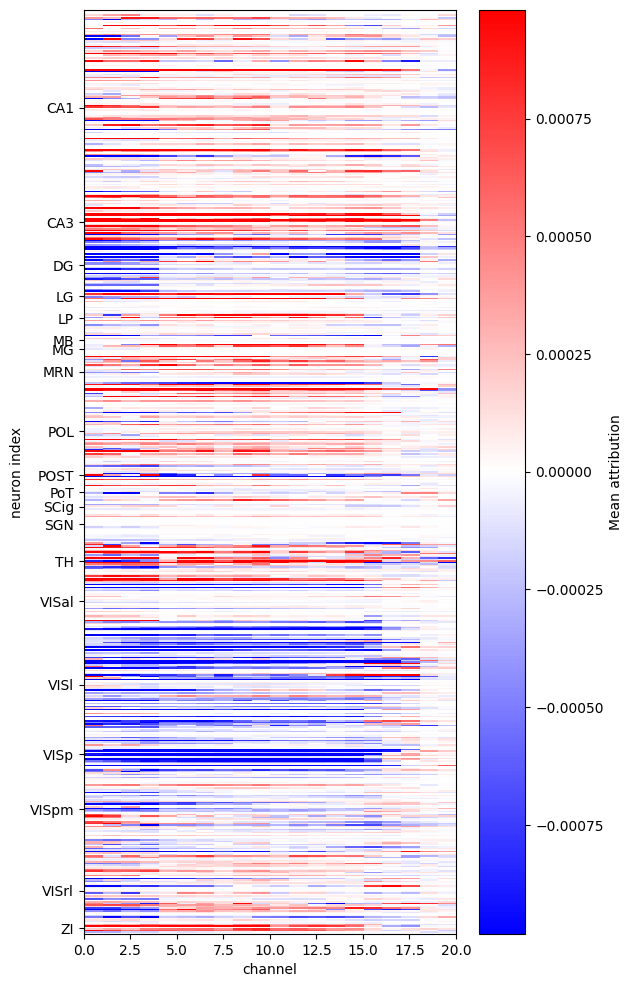

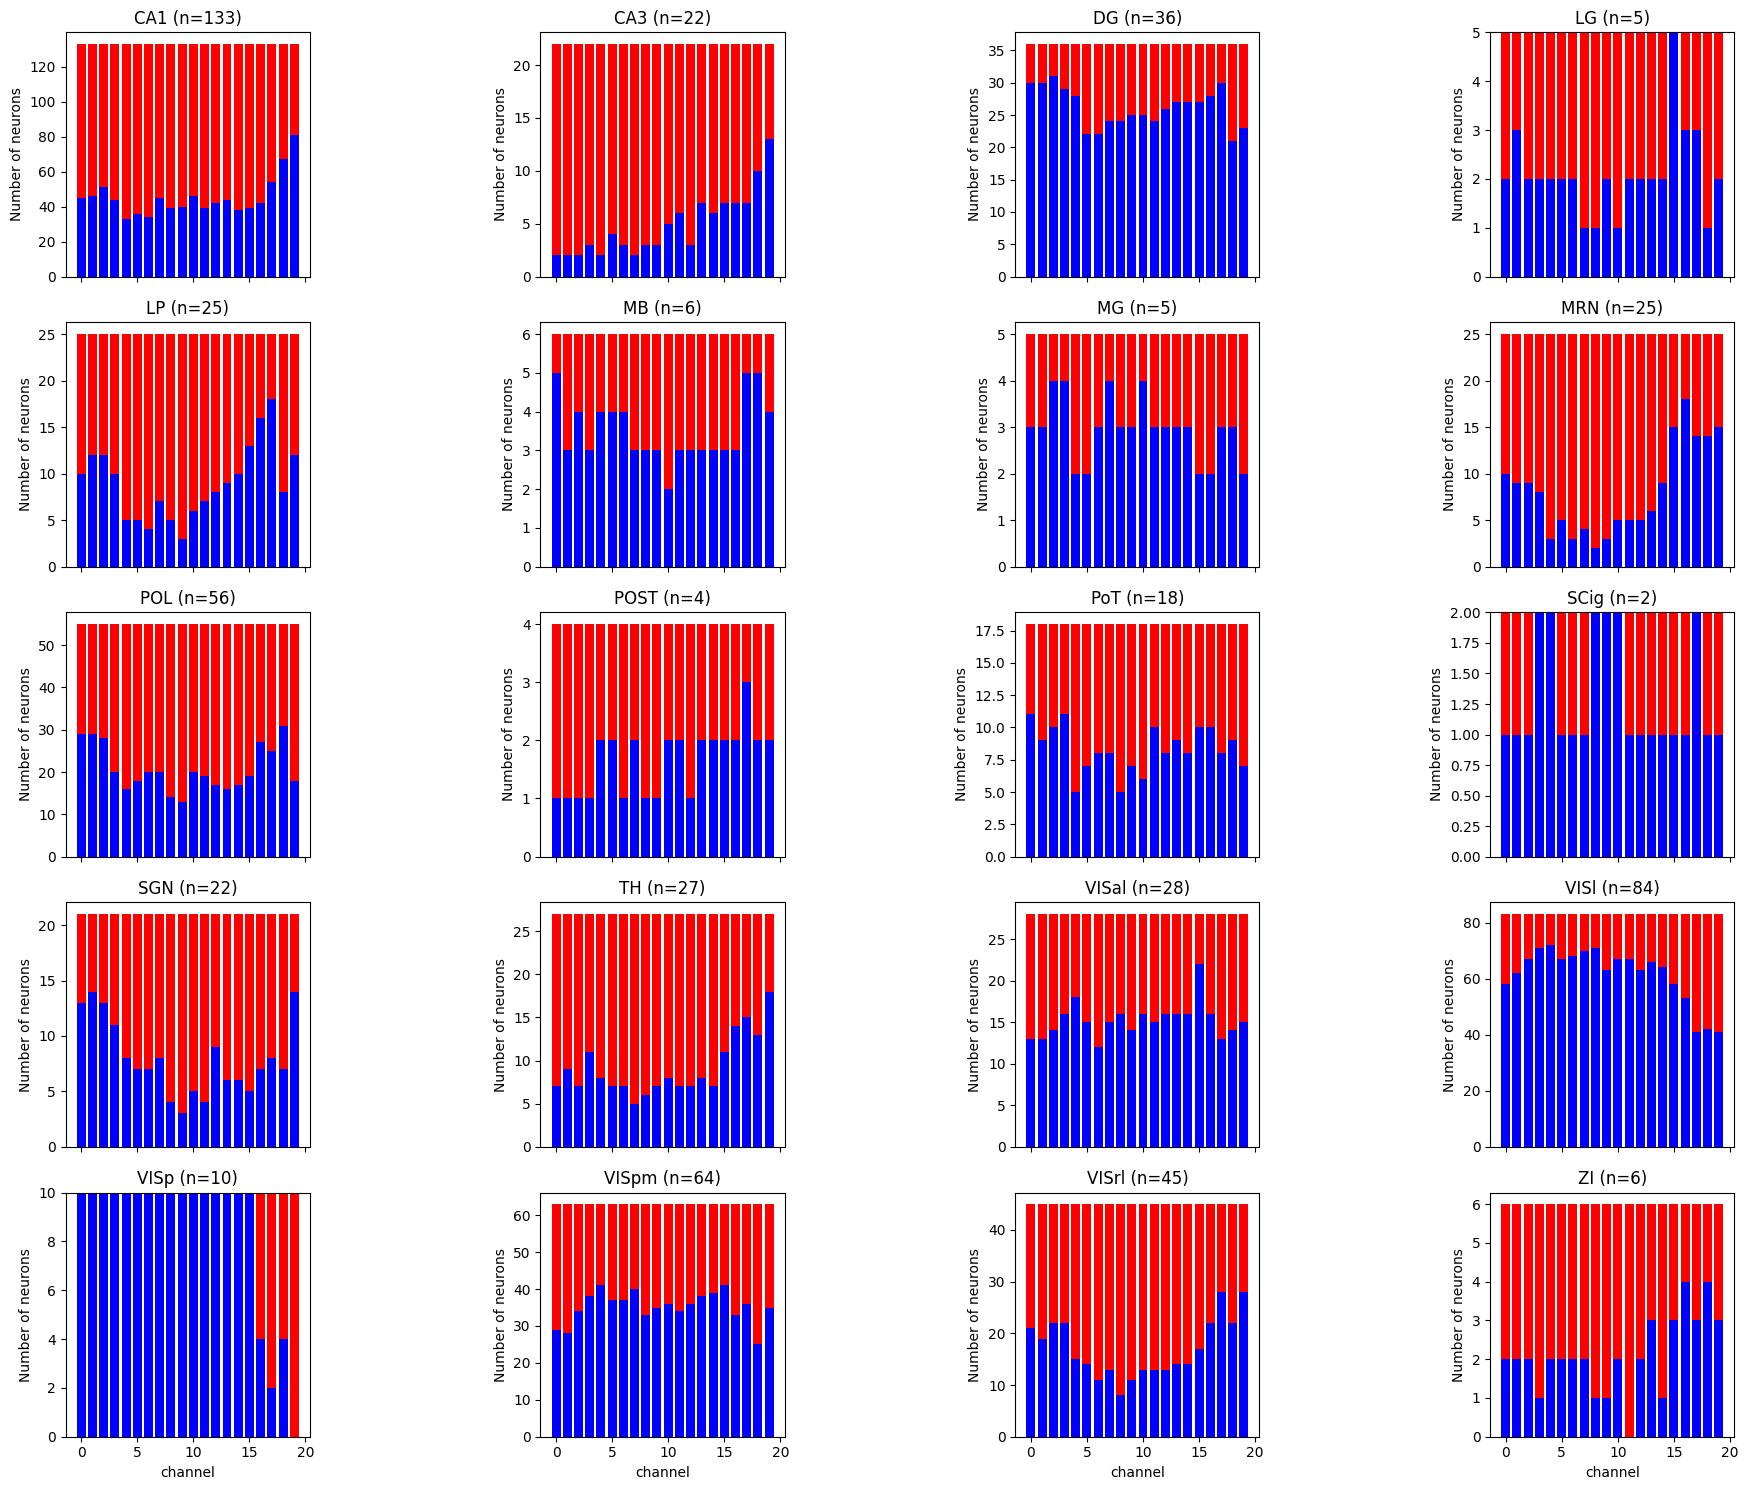

In [ ]:
locs = session_obj.units['structure_acronym']
sidx = np.argsort(locs.values)
sorted_locs = locs.values[sidx]

# for each area, find the first and last unit
areas = np.unique(sorted_locs)
first = []
last  = []
for area in areas:
    ind = sorted_locs == area
    first.append(np.where(ind)[0][0])
    last.append(np.where(ind)[0][-1])
middle = (np.array(first) + (np.array(last) - np.array(first)) / 2).astype(int)

# calculate the mean attribution across all channels
mean_attr_allchan = np.mean(mean_snippet_allchan, axis=1)

# plot mean_attr_allchan for all neurons
fig, ax = plt.subplots(1, 1, figsize=(6, 12))
im = ax.imshow(mean_attr_allchan[:,sidx].T, aspect='auto', cmap='bwr', interpolation='none', 
           vmin=-np.max(np.abs(mean_attr_allchan))/10, 
           vmax=np.max(np.abs(mean_attr_allchan))/10,
           extent=[0, mean_attr_allchan.shape[0], mean_attr_allchan.shape[1], 0])
ax.set_xlabel('channel')
ax.set_ylabel('neuron index')
ax.set_yticks(middle)
ax.set_yticklabels(areas)
cbar = plt.colorbar(mappable=ax.images[0], ax=ax)
cbar.set_label('Mean attribution')
plt.show()

# get the polarity of each neuron at each channel

# plot the above histogram for each area
fig, ax = plt.subplots(int(len(areas)/4), 4, figsize=(20, 15), sharex=True)
for areai, area in enumerate(areas):
    axr = ax[int(areai/4), areai%4]
    ind = ([session_obj.units['structure_acronym'] == area])[0]
    mean_attr_area = mean_attr_allchan[:,ind]
    # axr.hist(np.sum(np.sign(mean_attr_area) < 0, axis=1), bins=np.arange(num_channels+1)-0.5, color='b', alpha=0.7)
    # axr.hist(np.sum(np.sign(mean_attr_area) > 0, axis=1), bins=np.arange(num_channels+1)-0.5, color='r', alpha=0.7)
    sum_neg = np.sum(np.sign(mean_attr_area) < 0, axis=1)
    axr.bar(np.arange(len(sum_neg)), sum_neg, color='b')
    sum_pos = np.sum(np.sign(mean_attr_area) > 0, axis=1)
    axr.bar(np.arange(len(sum_pos)), sum_pos, bottom=sum_neg, color='r')
    axr.set_title(area + ' (n=' + str(sum(ind)) + ')')
    axr.set_aspect(1.0/axr.get_data_ratio(), adjustable='box')
    # if its the bottom row, add x label
    if areai >= (int(len(areas)/4)-1)*4:
        axr.set_xlabel('channel')
    axr.set_ylabel('Number of neurons')
plt.tight_layout()
plt.show()

## Find the reversal channel of each area

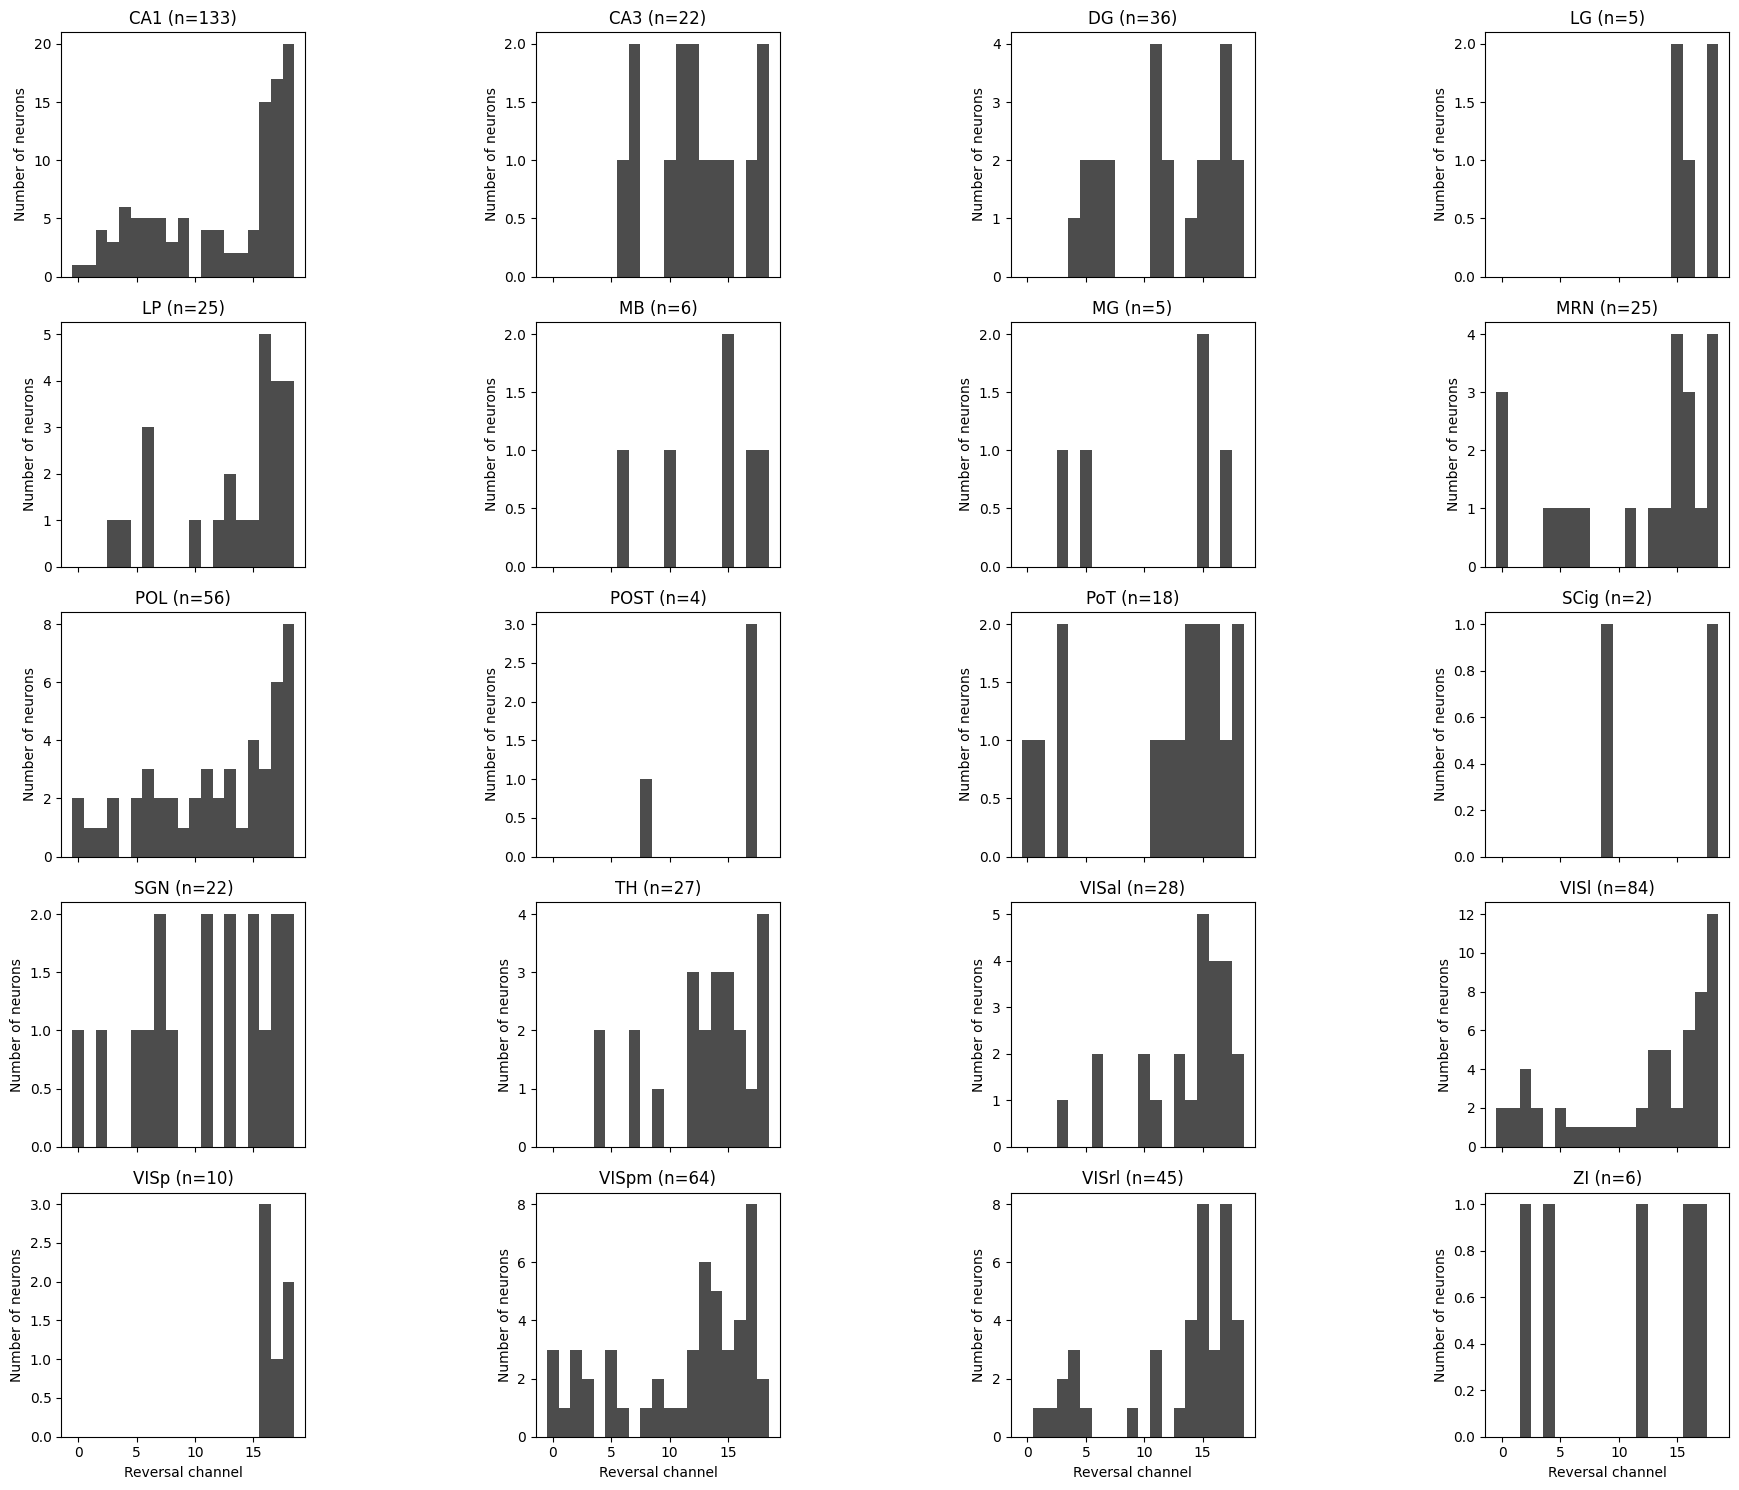

In [85]:
# smooth mean_snippet_allchan by convolving with a 2d gaussian
from scipy.ndimage import gaussian_filter
mean_snippet_allchan_smooth = np.zeros_like(mean_snippet_allchan)
for celli in range(mean_snippet_allchan.shape[2]):
    mean_snippet_allchan_smooth[:,:,celli] = gaussian_filter(mean_snippet_allchan[:,:,celli], sigma=(1, 1))
mean_attr_allchan_smooth = np.mean(mean_snippet_allchan_smooth, axis=1)
    
# for each neuron, find the channel that is closest to 0, ie the reversal channel
reversal_channel = np.zeros(spikes_obj.spkMat.shape[1])
for i in range(spikes_obj.spkMat.shape[1]):
    reversal_channel[i] = np.argmin(np.abs(mean_attr_allchan_smooth[:, i]))
# plot the histogram of reversal channels for each area
fig, ax = plt.subplots(int(len(areas)/4), 4, figsize=(20, 15), sharex=True)
for areai, area in enumerate(areas):
    axr = ax[int(areai/4), areai%4]
    ind = ([session_obj.units['structure_acronym'] == area])[0]
    rev_area = reversal_channel[ind]
    axr.hist(rev_area, bins=np.arange(num_channels)-0.5, color='k', alpha=0.7)
    axr.set_title(area + ' (n=' + str(sum(ind)) + ')')
    axr.set_aspect(1.0/axr.get_data_ratio(), adjustable='box')
    # if its the bottom row, add x label
    if areai >= (int(len(areas)/4)-1)*4:
        axr.set_xlabel('Reversal channel')
    axr.set_ylabel('Number of neurons')
plt.tight_layout()
plt.show()

## for each area, calculate the number of channels with negative attribution

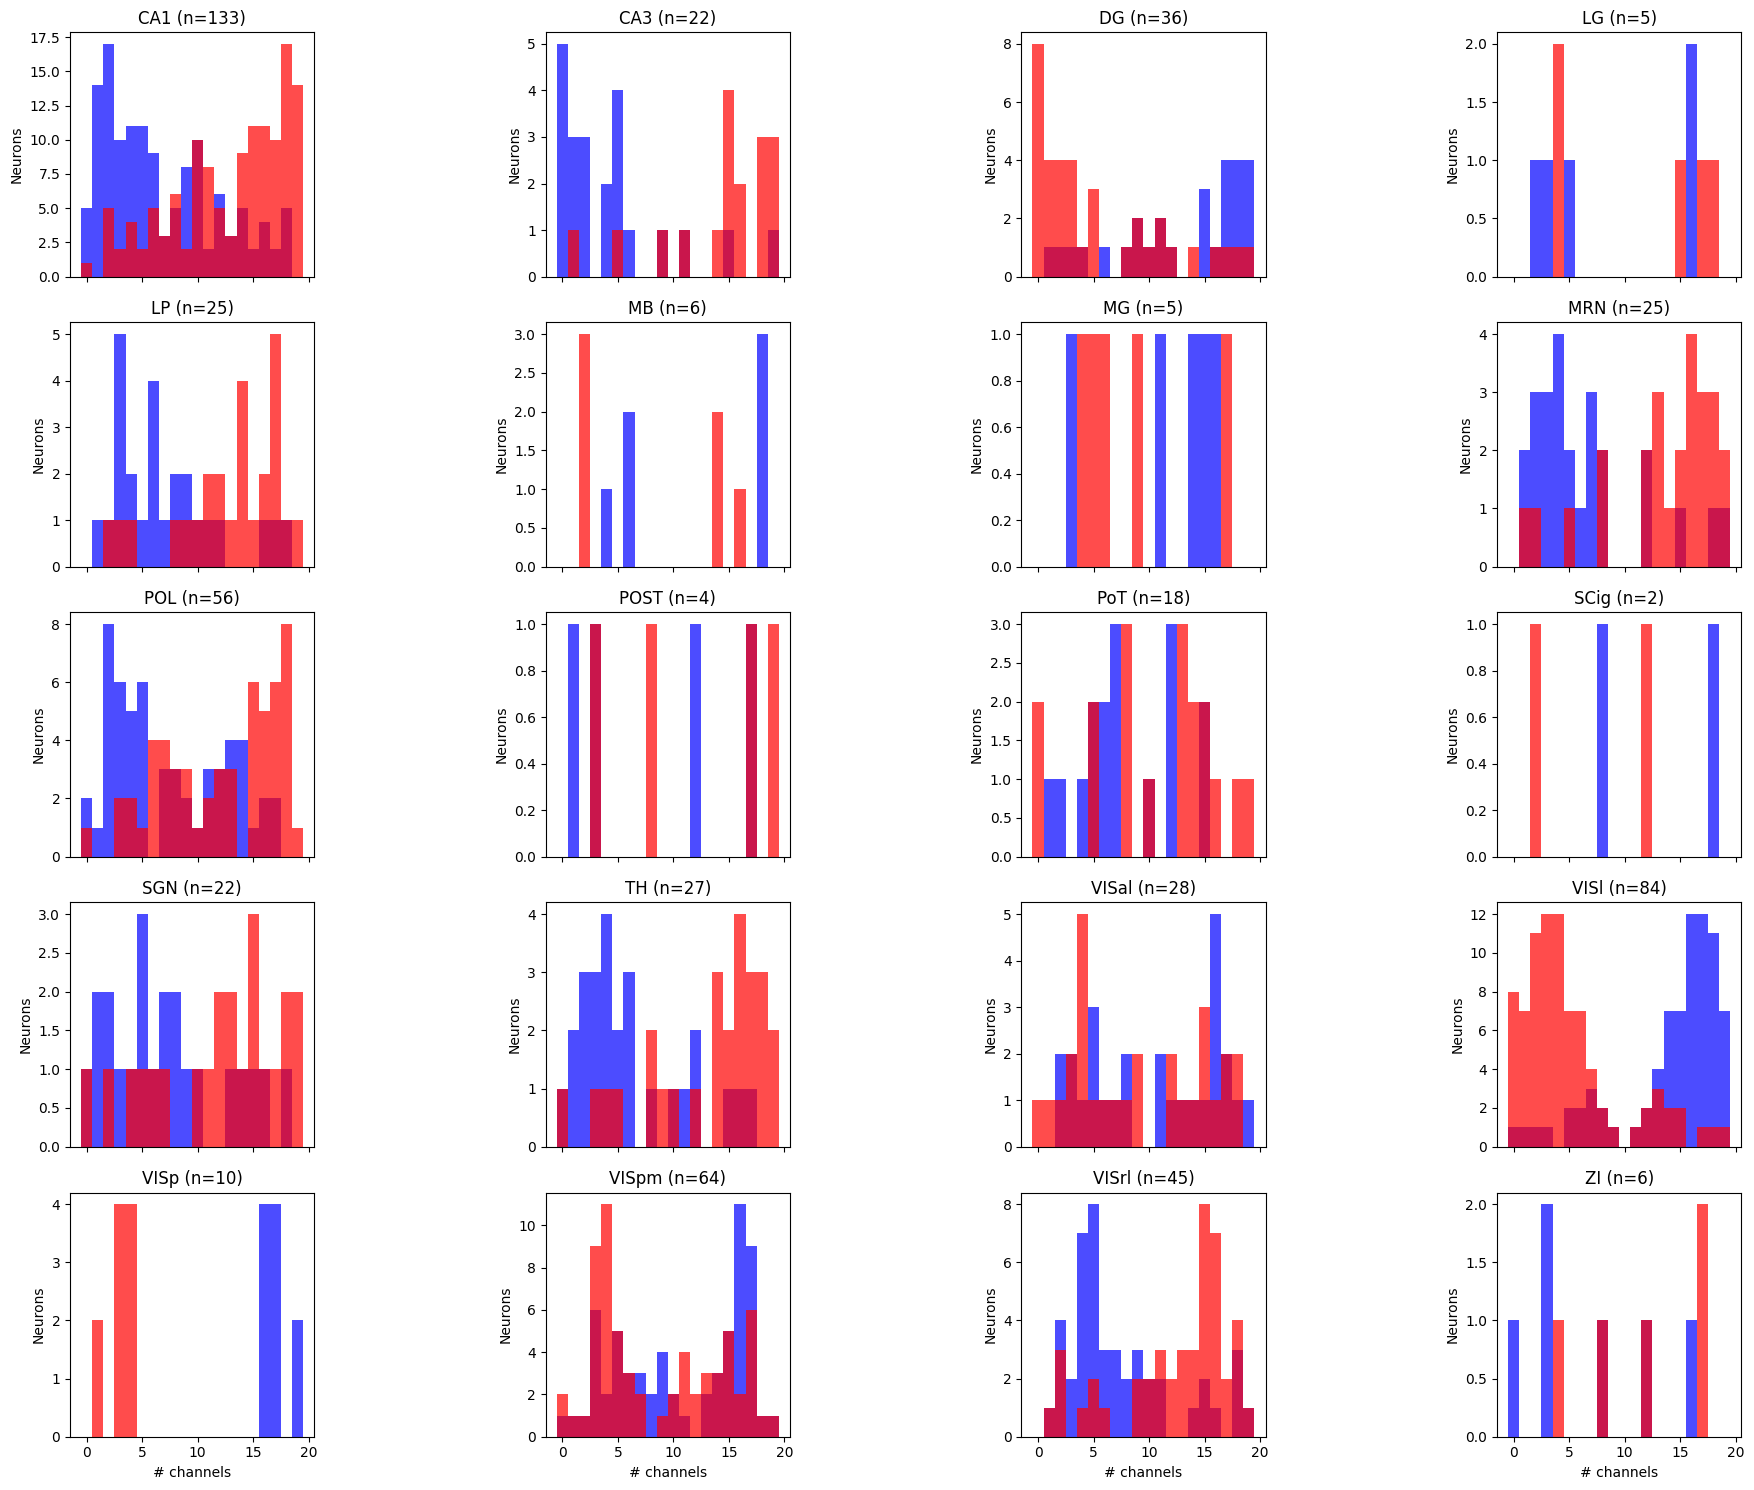

In [ ]:
neuron_neg_attr = np.sum(np.sign(mean_attr_allchan) < 0, axis=0)
neuron_pos_attr = np.sum(np.sign(mean_attr_allchan) > 0, axis=0)

fig, ax = plt.subplots(int(len(areas)/4), 4, figsize=(20, 15), sharex=True)
for areai, area in enumerate(areas):
    axr = ax[int(areai/4), areai%4]
    ind = ([session_obj.units['structure_acronym'] == area])[0]
    neuron_neg_attr_area = neuron_neg_attr[ind]
    neuron_pos_attr_area = neuron_pos_attr[ind]

    axr.hist(neuron_neg_attr_area, bins=np.arange(num_channels+1)-0.5, color='b', alpha=0.7)
    axr.hist(neuron_pos_attr_area, bins=np.arange(num_channels+1)-0.5, color='r', alpha=0.7)

    axr.set_title(area + ' (n=' + str(sum(ind)) + ')')
    axr.set_aspect(1.0/axr.get_data_ratio(), adjustable='box')
    if areai >= (int(len(areas)/4)-1)*4:
        axr.set_xlabel('# channels')
    axr.set_ylabel('Neurons')
plt.tight_layout()
plt.show()


## for each cluster, calculate the number of channels with negative attribution

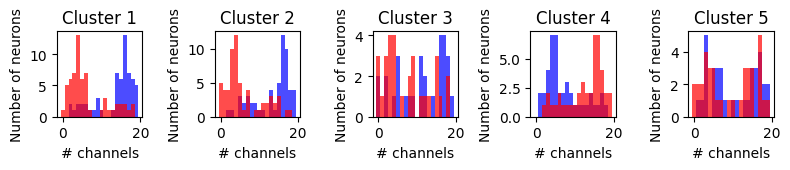

In [107]:
_, ax = plt.subplots(1, 5, figsize=(8, 6))
for clusteri in range(1, 6):
    ind = session_obj.units.index.isin(cluster_id[clusteri])
    neuron_neg_attr_cluster = neuron_neg_attr[ind]
    neuron_pos_attr_cluster = neuron_pos_attr[ind]

    ax[clusteri-1].hist(neuron_neg_attr_cluster, bins=np.arange(num_channels+1)-0.5, color='b', alpha=0.7)
    ax[clusteri-1].hist(neuron_pos_attr_cluster, bins=np.arange(num_channels+1)-0.5, color='r', alpha=0.7)
    ax[clusteri-1].set_xlabel('# channels')
    ax[clusteri-1].set_ylabel('Number of neurons')
    ax[clusteri-1].set_title(f'Cluster {clusteri}')
    
    # make the axis square
    ax[clusteri-1].set_aspect(1.0/ax[clusteri-1].get_data_ratio(), adjustable='box')

plt.tight_layout()
plt.show()


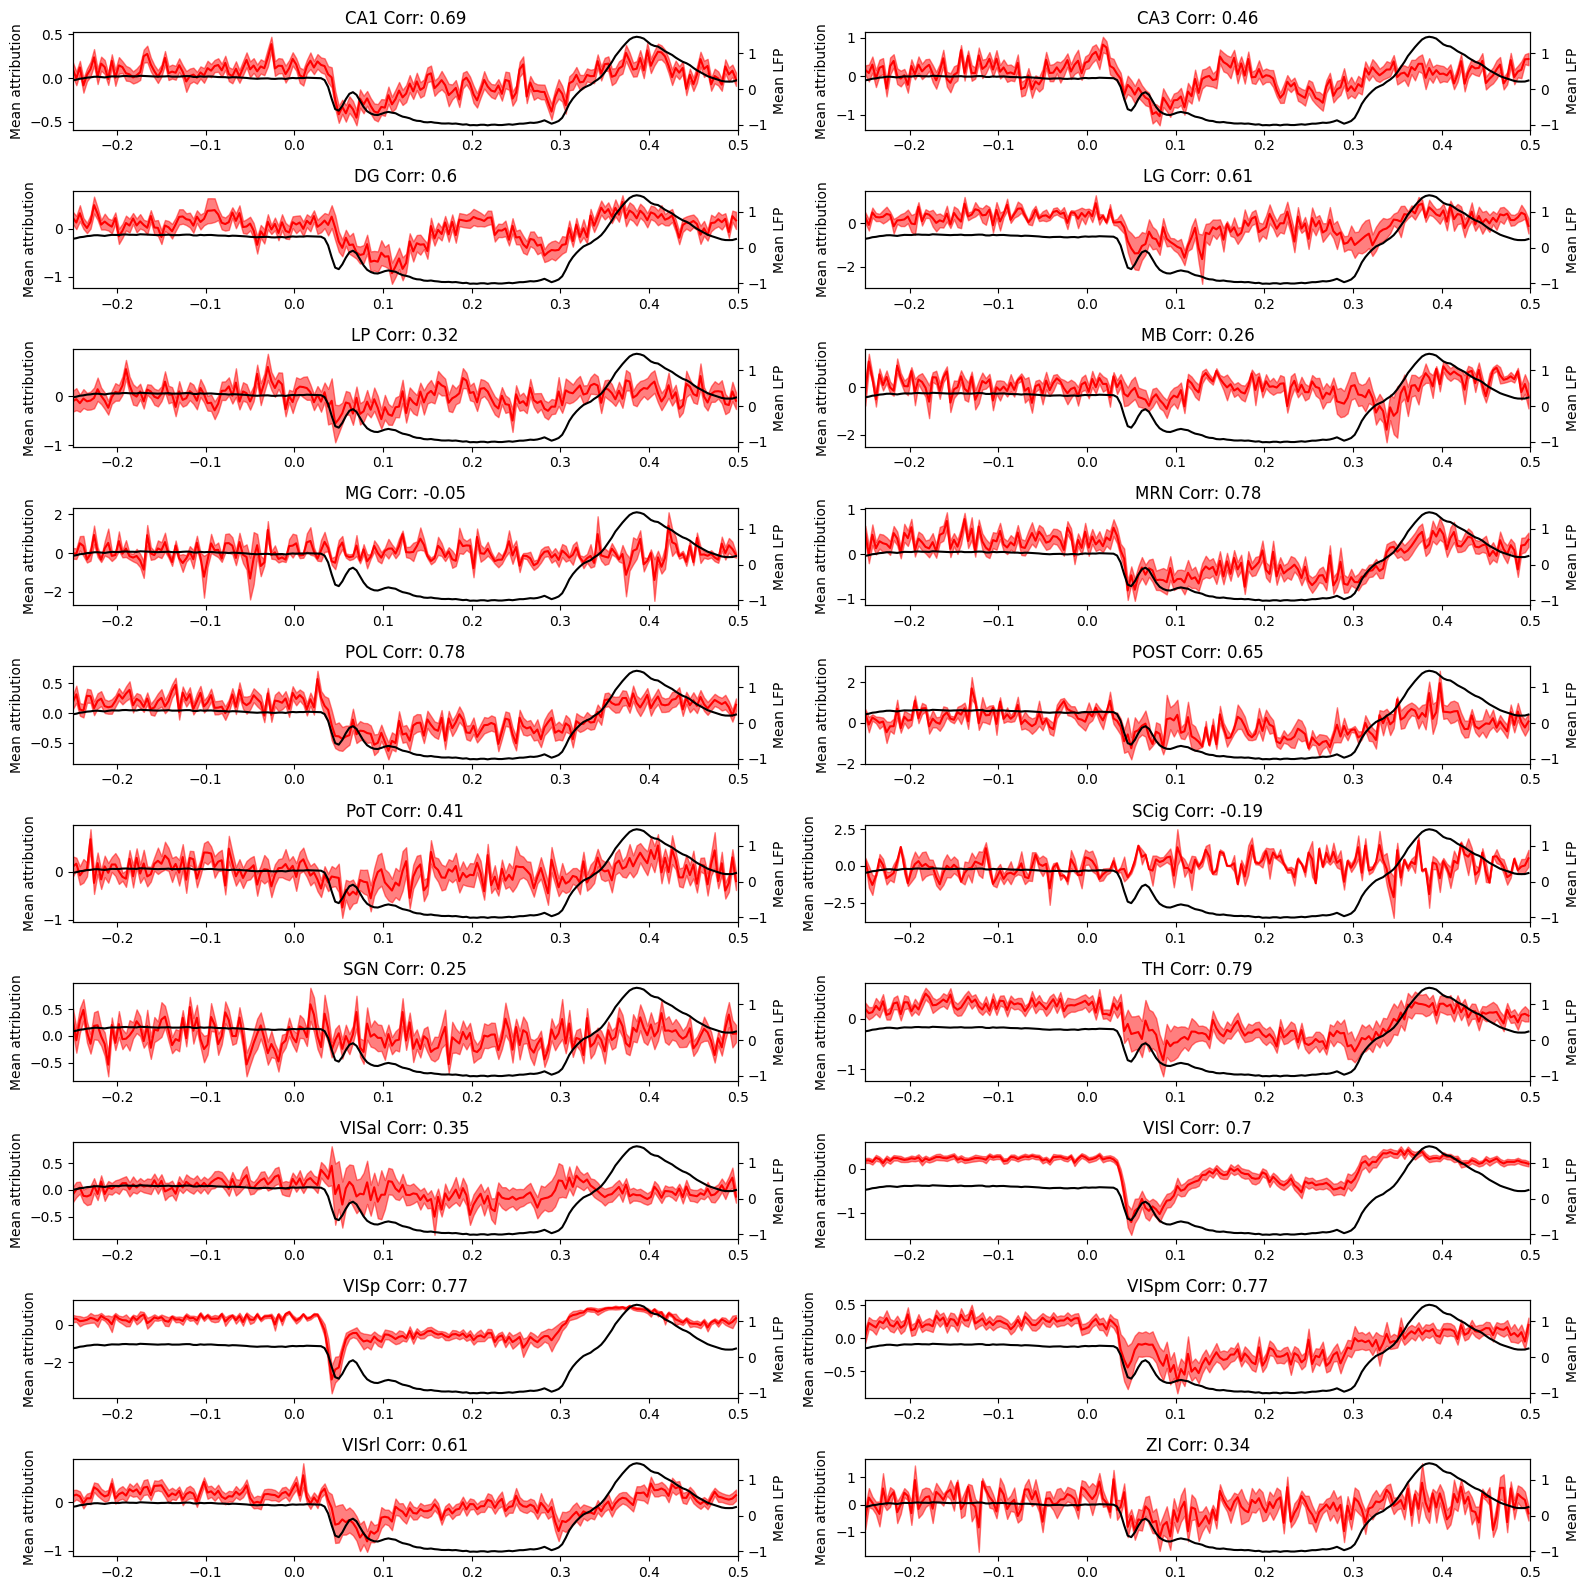

In [ ]:
broadband_attr = np.load(output_dir_models / 'attrs' / f'attribution_scores_chan{5}_band{0}.npy')
attr_snippets, lfp_snippets, t = plot_peri_stim_attr(broadband_attr, lfp_obj.lfpMat[:int(attr_dur/bin_size),5,0], session_obj,
                    spikes_obj.timestamps[:int(attr_dur/bin_size)], [-.25, 0.5])

## Spectral analysis

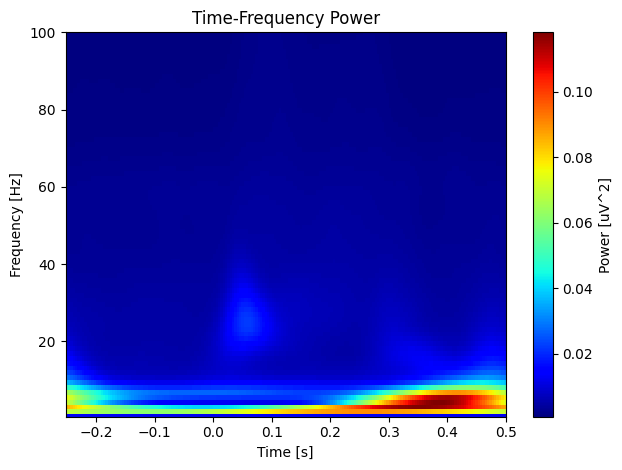

In [ ]:
# compute wavelet spectrogram
from wavelet_power import wavelet_power

tf, tf_all, itpc, frex = wavelet_power(lfp_snippets.T, t, Fs=250, freqs=[0.5, 100], num_frex=80)

# compute a spectrogram for the entire attribution data
tf, tf_all, itpc, frex = wavelet_power(lfp_obj.lfpMat[:int(attr_dur/bin_size),5,0].T.reshape(-1, 1), 
                                       spikes_obj.timestamps[:int(attr_dur/bin_size)], Fs=250, freqs=[0.5, 125], num_frex=80,
                                       normalization='none', mkplt=False)
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(np.log10(tf), aspect='auto', origin='lower', 
                          extent=[spikes_obj.timestamps[:int(attr_dur/bin_size)][0], spikes_obj.timestamps[:int(attr_dur/bin_size)][-1], frex[0], frex[-1]], 
                          cmap='jet', vmin=-3, vmax=1)
ax.set_ylim(frex[0], 15)
ax.set_xlim(spikes_obj.timestamps[:int(attr_dur/bin_size)][0], spikes_obj.timestamps[:int(attr_dur/bin_size)][0]+50)
ax.set_xlabel('Time (s)')
plt.colorbar(im, ax=ax, label='Log10 Power')
plt.show()

## Plot the peri-stim attribution of the different clusters

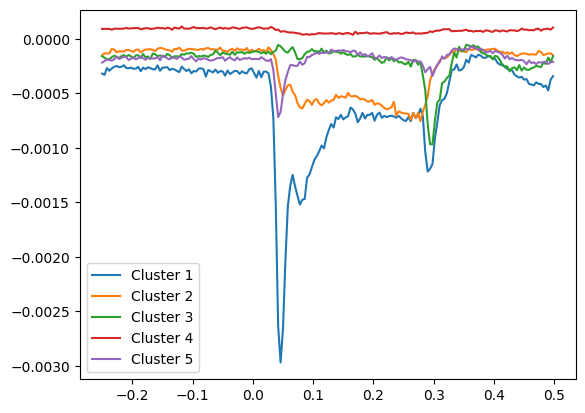

In [ ]:
mean_snippets = np.mean(attr_snippets, axis=0)
mean_clu1 = np.mean(mean_snippets[:, session_obj.units.index.isin(cluster_id[1])] , axis=1)
mean_clu2 = np.mean(mean_snippets[:, session_obj.units.index.isin(cluster_id[2])] , axis=1)
mean_clu3 = np.mean(mean_snippets[:, session_obj.units.index.isin(cluster_id[3])] , axis=1)
mean_clu4 = np.mean(mean_snippets[:, session_obj.units.index.isin(cluster_id[4])] , axis=1)
mean_clu5 = np.mean(mean_snippets[:, session_obj.units.index.isin(cluster_id[5])] , axis=1) 

plt.plot(t, mean_clu1, label='Cluster 1')
plt.plot(t, mean_clu2, label='Cluster 2')
plt.plot(t, mean_clu3, label='Cluster 3')   
plt.plot(t, mean_clu4, label='Cluster 4')
plt.plot(t, mean_clu5, label='Cluster 5')
plt.legend()
plt.show()

plt.imshow(lfp_snippets, aspect='auto', cmap='gray', extent=[t[0], t[-1], 0, lfp_snippets.shape[0]])
plt.xlabel('Time (s)')
plt.ylabel('Trial')
plt.title('LFP Snippets')
plt.colorbar(label='Amplitude')
plt.show()

In [ ]:
# correlation between attribution scores and linear model weights
weights = linear_model.model.coef_

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sns.regplot(x=weights, y=mean_attribution[5,0,:], ax=ax, color='k')
ax.set_xlabel('Linear model weights')
ax.set_ylabel('attribution score')
ax.set_title(f'corr  = {np.corrcoef(weights, mean_attribution[5,0,:])[0,1]:.2f}')
ax.set_xlim([-0.1, 0.1])
plt.show()

## Comparison of attribution dependency on LFP sign

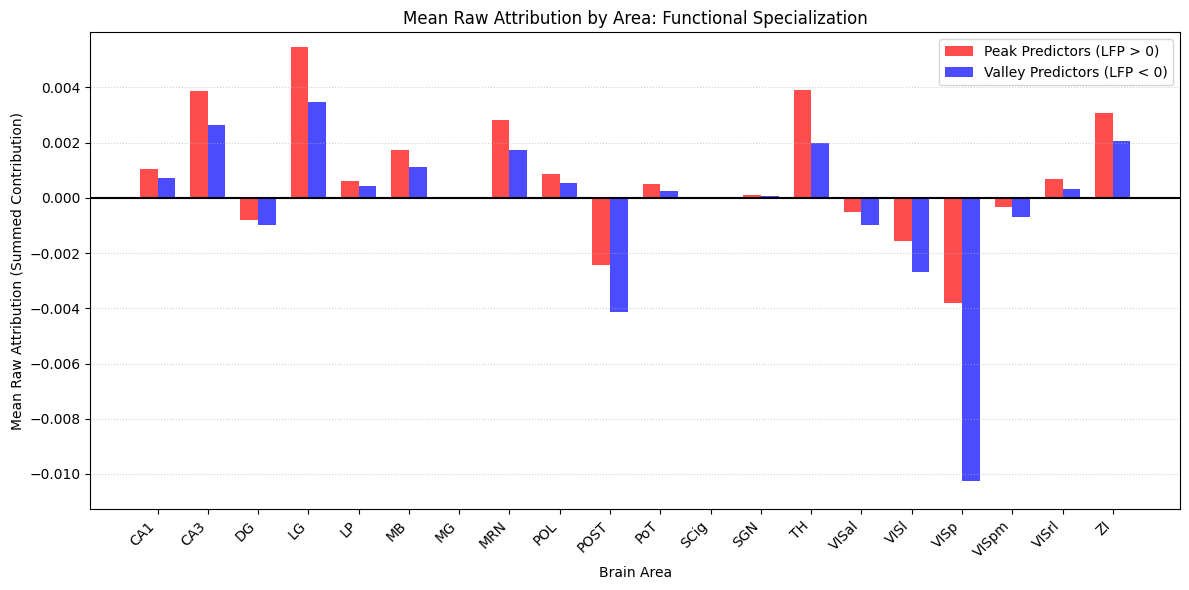

In [664]:
# sparse_attr = np.load(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\attrs\1044385384\attribution_scores_chan5_band0.npz')
# attrs = coo_matrix((sparse_attr['data'], (sparse_attr['row'], sparse_attr['col'])), shape=sparse_attr['shape']).toarray()

attrs = np.load(output_dir_models / 'attrs' / f'attribution_scores_chan{5}_band{0}.npy')
total_attr = np.nansum(np.abs(attrs), axis=1, keepdims=True)
attrs = attrs / (total_attr + 1e-10) # convert to relative attribution

N_regions = len(areas)
region_names = list(areas)

target_lfp = lfp_obj.lfpMat[:int(attr_dur/bin_size),5,0]
# Create boolean masks for LFP signs
peak_mask = (target_lfp > 0)
valley_mask = (target_lfp < 0)

# Initialize arrays to store the results
peak_mean_attribution = np.zeros(N_regions)
valley_mean_attribution = np.zeros(N_regions)

# --- 2. Calculate Mean Raw Attribution Per Area Per LFP Sign ---

for r_idx, region in enumerate(region_names):
    # Mask for all neurons belonging to the current region
    area_neuron_mask = (locs == region)
    
    # 1. Calculate the raw attribution time series for this area (summed across neurons)
    # Result is a 1D array (N_timepoints,) showing the total raw attribution for the region at each moment
    total_raw_attribution_time_series = np.sum(attrs[:, area_neuron_mask], axis=1) / np.sum(area_neuron_mask)
    
    # 2. Segment and average the total raw attribution based on LFP sign
    
    # Mean raw attribution during LFP Peaks (target LFP > 0)
    if np.any(peak_mask):
        peak_mean_attribution[r_idx] = np.mean(total_raw_attribution_time_series[peak_mask])
    
    # Mean raw attribution during LFP Valleys (target LFP < 0)
    if np.any(valley_mask):
        valley_mean_attribution[r_idx] = np.mean(total_raw_attribution_time_series[valley_mask])


# --- 3. Visualization: Comparison Bar Chart ---

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(N_regions)     # Label locations (0, 1, 2, ...)
width = 0.35                 # Width of the individual bars

# Calculate Y-limits for symmetry around zero
y_min = min(peak_mean_attribution.min(), valley_mean_attribution.min()) * 1.1
y_max = max(peak_mean_attribution.max(), valley_mean_attribution.max()) * 1.1

# 1. Plot Peak Predictors (LFP > 0): Shifted to the left
rects1 = ax.bar(x - width/2, peak_mean_attribution, width, 
                label='Peak Predictors (LFP > 0)', color='r', alpha=0.7)

# 2. Plot Valley Predictors (LFP < 0): Shifted to the right
rects2 = ax.bar(x + width/2, valley_mean_attribution, width, 
                label='Valley Predictors (LFP < 0)', color='b', alpha=0.7)

# Add Labels and Cosmetics
ax.set_title('Mean Raw Attribution by Area: Functional Specialization')
ax.set_ylabel('Mean Raw Attribution (Summed Contribution)')
ax.set_xlabel('Brain Area')
ax.set_xticks(x)
ax.set_xticklabels(region_names, rotation=45, ha='right')
ax.axhline(0, color='k', linewidth=1.5) # Zero line for reference
ax.legend(loc='upper right')

# Set symmetrical Y-axis limits
ax.set_ylim(y_min, y_max)
ax.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
N_regions = len(areas)
region_names = list(areas)

# --- 1. Initialize 3D Storage Array ---
# Shape: (N_channels, N_regions, 2) -> We store PEAK and VALLEY scores separately
# New Shape: (N_channels, N_regions) for PEAK and (N_channels, N_regions) for VALLEY
peak_scores_by_channel = np.zeros((num_channels, N_regions))
valley_scores_by_channel = np.zeros((num_channels, N_regions))

# --- 2. Outer Loop: Iterate over Channels ---
for chan_i in range(num_channels):
    # --- A. Load Data and Target LFP ---
    
    # Load Attribution Scores for the current channel
    # Note: Band is hardcoded to 0 based on your original code
    attrs = np.load(output_dir_models / 'attrs' / f'attribution_scores_chan{chan_i}_band{0}.npy')
    
    # Target LFP for the current channel
    # Note: Band is hardcoded to 0 based on your original code
    target_lfp = lfp_obj.lfpMat[:int(attr_dur/bin_size), chan_i, 0]
    
    # Normalize Attribution (Relative attribution)
    # The original code normalizes by the total absolute attribution sum across neurons
    total_attr = np.nansum(np.abs(attrs), axis=1, keepdims=True)
    attrs = attrs / (total_attr + 1e-10) 

    # Create boolean masks for LFP signs (applies to current channel's LFP)
    peak_mask = (target_lfp > 0)
    valley_mask = (target_lfp < 0)

    # --- B. Inner Loop: Calculate Attribution per Region (for the current channel) ---
    for r_idx, region in enumerate(region_names):
        # Mask for all neurons belonging to the current region
        area_neuron_mask = (locs == region)
        n_neurons_in_region = np.sum(area_neuron_mask)
        
        # 1. Calculate the raw attribution time series for this area (summed across neurons)
        # This is the Normalized Dominance Score (Intensity)
        total_raw_attribution_time_series = np.sum(attrs[:, area_neuron_mask], axis=1) / n_neurons_in_region
        
        # 2. Segment and average the total raw attribution based on LFP sign
        
        # Mean raw attribution during LFP Peaks (target LFP > 0)
        if np.any(peak_mask):
            peak_scores_by_channel[chan_i, r_idx] = np.mean(total_raw_attribution_time_series[peak_mask])
        
        # Mean raw attribution during LFP Valleys (target LFP < 0)
        if np.any(valley_mask):
            valley_scores_by_channel[chan_i, r_idx] = np.mean(total_raw_attribution_time_series[valley_mask])

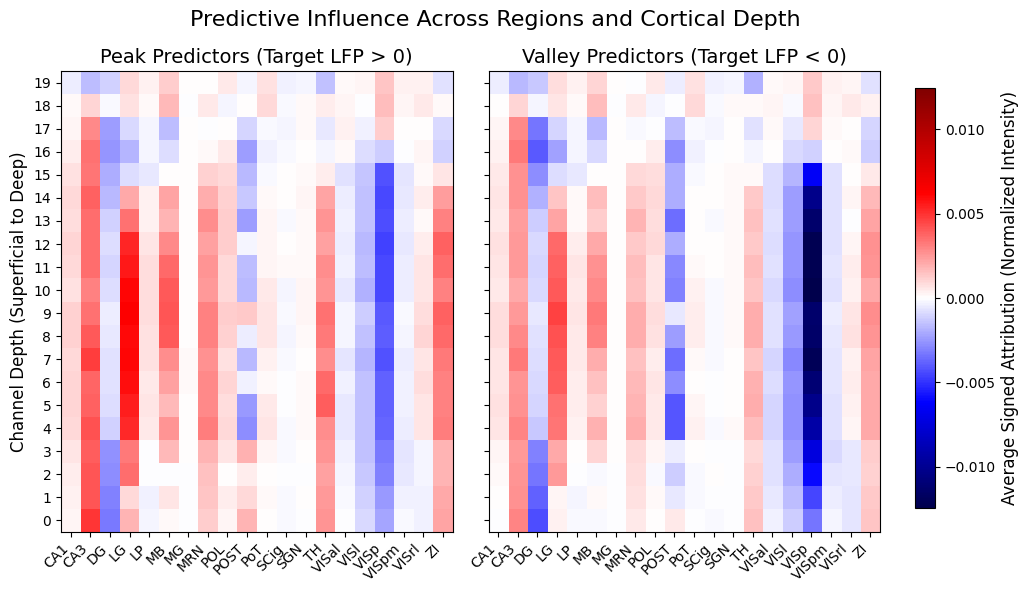

In [ ]:
import matplotlib.colors as colors

# --- 1. Determine the Global Symmetrical Color Scale ---
# Find the absolute maximum score across both matrices to ensure the color scales are identical and symmetrical around zero.
global_max = max(np.abs(peak_scores_by_channel).max(), 
                 np.abs(valley_scores_by_channel).max())
vmax = global_max
vmin = -global_max


# --- 2. Visualization: Paired Heatmaps ---
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

# Define the Diverging Colormap (e.g., seismic or coolwarm)
cmap = plt.cm.seismic

# --- Heatmap 1: Peak Predictors (Target LFP > 0) ---
im1 = axes[0].imshow(peak_scores_by_channel, 
                     aspect='auto', 
                     cmap=cmap, 
                     vmin=vmin, 
                     vmax=vmax,
                     origin='lower') # Use origin='lower' to plot Channel 0 at the bottom

axes[0].set_title('Peak Predictors (Target LFP > 0)', fontsize=14)
axes[0].set_xticks(np.arange(N_regions))
axes[0].set_xticklabels(region_names, rotation=45, ha='right')
axes[0].set_ylabel('Channel Depth (Superficial to Deep)', fontsize=12)

# Set Y-ticks to reflect channel numbers
channel_labels = np.arange(num_channels)
axes[0].set_yticks(channel_labels)
axes[0].set_yticklabels(channel_labels)


# --- Heatmap 2: Valley Predictors (Target LFP < 0) ---
im2 = axes[1].imshow(valley_scores_by_channel, 
                     aspect='auto', 
                     cmap=cmap, 
                     vmin=vmin, 
                     vmax=vmax,
                     origin='lower')

axes[1].set_title('Valley Predictors (Target LFP < 0)', fontsize=14)
axes[1].set_xticks(np.arange(N_regions))
axes[1].set_xticklabels(region_names, rotation=45, ha='right')


# --- Add a single shared Colorbar ---
# Create space for the colorbar
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

# Link the colorbar to the heatmap image object (im1 or im2, as they share vmin/vmax)
cbar = fig.colorbar(im1, cax=cbar_ax)
cbar.set_label('Average Signed Attribution (Normalized Intensity)', fontsize=12)

plt.suptitle('Predictive Influence Across Regions and Cortical Depth', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to fit colorbar
plt.show()

## Compute rank matrix

In [ ]:
sparse_attr = np.load(r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022\spikes2lfp\attrs\1044385384\attribution_scores_chan5_band0.npz')
attrs = coo_matrix((sparse_attr['data'], (sparse_attr['row'], sparse_attr['col'])), shape=sparse_attr['shape']).toarray()
abs_attrs = np.abs(attrs)

rank_matrix = np.zeros_like(attrs)

n_neurons = attrs.shape[1]
n_timepoints = attrs.shape[0]

for ti in range(n_timepoints):
    # Get absolute values for this time point
    abs_values_t = abs_attrs[ti, :]
    
    # 1. Get indices that would sort the absolute values in ASCENDING order
    # (Least influential neuron's index is first)
    sorted_indices_ascending = np.argsort(abs_values_t)
    
    # 2. Assign ranks based on the ascending order. 
    # The last element in the ascending sort is the most influential (Rank 1).
    # The first element is the least influential (Rank n_neurons).
    
    # Ranks range from 1 to n_neurons.
    # The array np.arange(n_neurons, 0, -1) creates ranks [n, n-1, ..., 1]
    ranks_descending = np.arange(n_neurons, 0, -1)
    
    # The assignment below is the critical step:
    # It assigns the rank (from ranks_descending) to the neuron index 
    # specified by sorted_indices_ascending.
    rank_matrix[ti, sorted_indices_ascending] = ranks_descending
    

## Dynamic stability analysis

In [616]:
K = 40
n_timepoints = rank_matrix.shape[0]
locs = spikes_obj.units['structure_acronym'].values

jaccard_scores = np.zeros(n_timepoints - 1)
jaccard_scores_regional = np.zeros(n_timepoints - 1)

# Iterate from the first time point (t=0) up to the second-to-last time point
for ti in range(n_timepoints - 1):
    # A. Get the set of influential neurons at time t (S_t)
    # The rank_matrix holds ranks 1 to 623. We want indices where rank <= K.
    # Convert to a set for efficient intersection/union operations.
    indices_t = np.where(rank_matrix[ti, :] <= K)[0]
    regions_t_array = locs[indices_t]
    
    S_t = set(indices_t)
    C_t = set(regions_t_array)
    
    # B. Get the set of influential neurons at time t+1 (S_t+1)
    indices_t_plus_1 = np.where(rank_matrix[ti+1, :] <= K)[0]
    regions_t_plus_1_array = locs[indices_t_plus_1]
    
    S_t_plus_1 = set(indices_t_plus_1)
    C_t_plus_1 = set(regions_t_plus_1_array)
    
    # C. Calculate Intersection and Union
    intersection = len(S_t.intersection(S_t_plus_1))
    union = len(S_t.union(S_t_plus_1))
    
    intersection_regions = len(C_t.intersection(C_t_plus_1))
    union_regions = len(C_t.union(C_t_plus_1))   

    # D. Calculate Jaccard Similarity (Intersection / Union)
    # Handle the unlikely case of a zero union (though rank_matrix ensures K elements)
    if union > 0:
        jaccard_scores[ti] = intersection / union
    else:
        jaccard_scores[ti] = 0
        
    if union_regions > 0:
        jaccard_scores_regional[ti] = intersection_regions / union_regions
    else:
        jaccard_scores_regional[ti] = 0    

visusalizing results


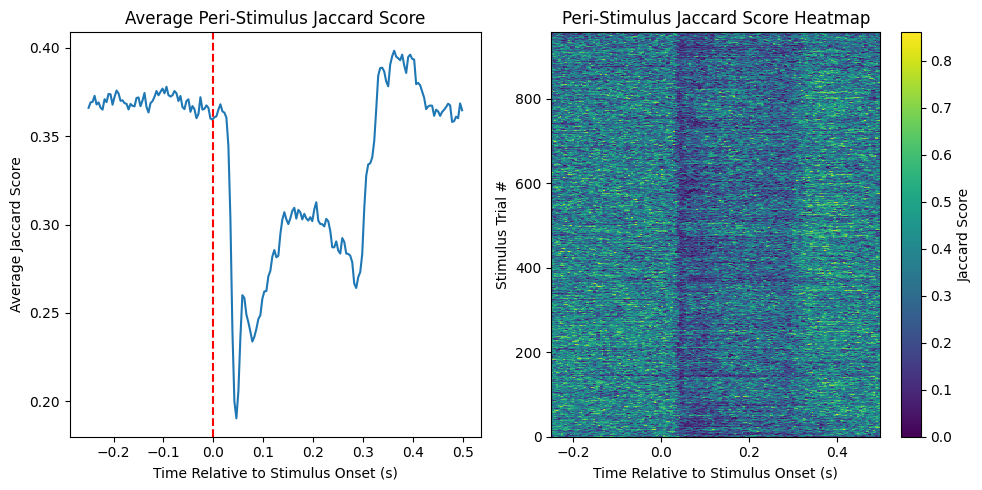

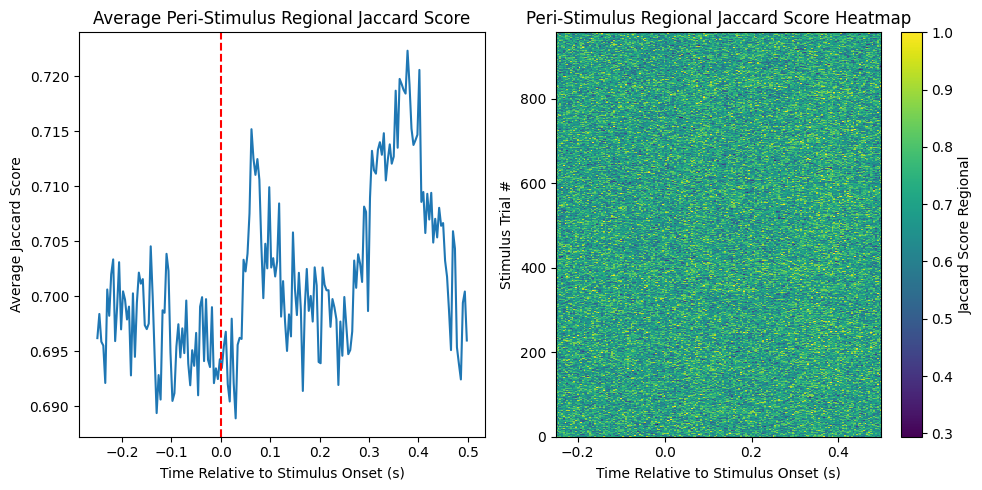

In [618]:
# calculate stimulus triggered Jaccard score
time_win = [-.25, .5]
t = np.arange(time_win[0], time_win[1], bin_size)
timestamps = spikes_obj.timestamps[:int(attr_dur/bin_size)]
stim_st = session_obj.stimulus_presentation.start_time
stim_st = stim_st[((stim_st - np.abs(t[0])) > timestamps[0]) & ((stim_st + np.abs(t[-1])) < timestamps[-1])]
stim_st = stim_st.values

n_bins_in_snippet = len(t)

# Initialize the storage matrix: (n_trials, n_bins)
# The second dimension is the number of time bins in your window.
jaccard_snippets = np.zeros((len(stim_st), n_bins_in_snippet))
jaccard_snippets_regions = np.zeros((len(stim_st), n_bins_in_snippet))

for i in range(len(stim_st)):
    # Calculate the timestamp (in seconds) corresponding to the start of the snippet window
    start_time_sec = stim_st[i] + time_win[0]
    
    # Find the index in the global timestamps array closest to the start time
    start_idx = np.argmin(np.abs(timestamps - start_time_sec))
    
    # ASSIGN the snippet to the current row (i)
    # The snippet runs from start_idx for a duration of n_bins_in_snippet
    jaccard_snippets[i, :] = jaccard_scores[start_idx : start_idx + n_bins_in_snippet]
    jaccard_snippets_regions[i, :] = jaccard_scores_regional[start_idx : start_idx + n_bins_in_snippet]

# --- Visualization ---
print('visusalizing results')

fig, ax = plt.subplots(1,2,figsize=(10,5))

# Plot the Average Time Course
ax[0].plot(t, np.mean(jaccard_snippets, axis=0))
ax[0].set_title('Average Peri-Stimulus Jaccard Score')
ax[0].set_xlabel('Time Relative to Stimulus Onset (s)')
ax[0].set_ylabel('Average Jaccard Score')
ax[0].axvline(0, color='r', linestyle='--')

# Plot the Heatmap
im = ax[1].imshow(jaccard_snippets, aspect='auto', cmap='viridis', 
           extent=[t[0], t[-1], len(stim_st), 0], 
           interpolation='none')
ax[1].set_xlabel('Time Relative to Stimulus Onset (s)')
ax[1].set_ylabel('Stimulus Trial #')
ax[1].set_title('Peri-Stimulus Jaccard Score Heatmap')
cbar = plt.colorbar(mappable=im, ax=ax[1])
cbar.set_label('Jaccard Score')
ax[1].invert_yaxis()  # Invert y-axis so trial 1 is at the top
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1,2,figsize=(10,5))

# Plot the Average Time Course
ax[0].plot(t, np.mean(jaccard_snippets_regions, axis=0))
ax[0].set_title('Average Peri-Stimulus Regional Jaccard Score')
ax[0].set_xlabel('Time Relative to Stimulus Onset (s)')
ax[0].set_ylabel('Average Jaccard Score')
ax[0].axvline(0, color='r', linestyle='--')

# Plot the Heatmap
im = ax[1].imshow(jaccard_snippets_regions, aspect='auto', cmap='viridis', 
           extent=[t[0], t[-1], len(stim_st), 0], 
           interpolation='none')
ax[1].set_xlabel('Time Relative to Stimulus Onset (s)')
ax[1].set_ylabel('Stimulus Trial #')
ax[1].set_title('Peri-Stimulus Regional Jaccard Score Heatmap')
cbar = plt.colorbar(mappable=im, ax=ax[1])
cbar.set_label('Jaccard Score Regional')
ax[1].invert_yaxis()  # Invert y-axis so trial 1 is at the top
plt.tight_layout()
plt.show()


## Regional Dominance Score

In [619]:
areas = np.unique(locs)
N_regions = len(areas)
N_bins_in_snippet = len(t) 
N_trials = len(stim_st)

InverseRank_Matrix = 1/rank_matrix
dominance_scores_3D = np.zeros((N_trials, N_regions, N_bins_in_snippet))

region_masks = {}
for region in areas:
    # Mask is True where the neuron belongs to the current region
    region_masks[region] = (locs == region)

# Convert region_list to an ordered index for the 3D array
region_names = list(areas)

# Iterate through each stimulus trial
for i in range(N_trials):
    # 1. Determine the start index in the full InverseRank matrix
    start_time_sec = stim_st[i] + time_win[0]
    start_idx = np.argmin(np.abs(timestamps - start_time_sec))
    
    # 2. Extract the snippet (2D array: N_bins_in_snippet x N_neurons)
    snippet = InverseRank_Matrix[start_idx : start_idx + N_bins_in_snippet, :]
    
    # 3. Calculate Dominance Score for each region in the snippet
    for r_idx, region in enumerate(region_names):
        mask = region_masks[region]
        
        # NumPy magic: Sum the Inverse Ranks only for neurons where the mask is True.
        # This gives a 1D array of scores (one score per time bin in the snippet).
        dominance_score_time_series = np.sum(snippet[:, mask], axis=1) / np.sum(mask)
        
        # 4. Store the result in the 3D array
        dominance_scores_3D[i, r_idx, :] = dominance_score_time_series
        

average_dominance_scores = np.mean(dominance_scores_3D, axis=0) 
err_dominance_scores     = np.std(dominance_scores_3D, axis=0) / np.sqrt(N_trials)

total_influence_time_series = np.sum(average_dominance_scores, axis=0)

# Reshape total_influence_time_series for broadcasting: (1, N_bins_in_snippet)
total_influence_reshaped = total_influence_time_series[np.newaxis, :]

# 2. Calculate Proportional Influence
# This divides the mean score of EACH area by the total mean score across all areas at that time bin.
# Shape: (N_regions, N_bins_in_snippet)
proportional_influence = average_dominance_scores / total_influence_reshaped

# Handle division by zero where total influence is zero (set proportion to zero)
proportional_influence = np.nan_to_num(proportional_influence, nan=0.0)


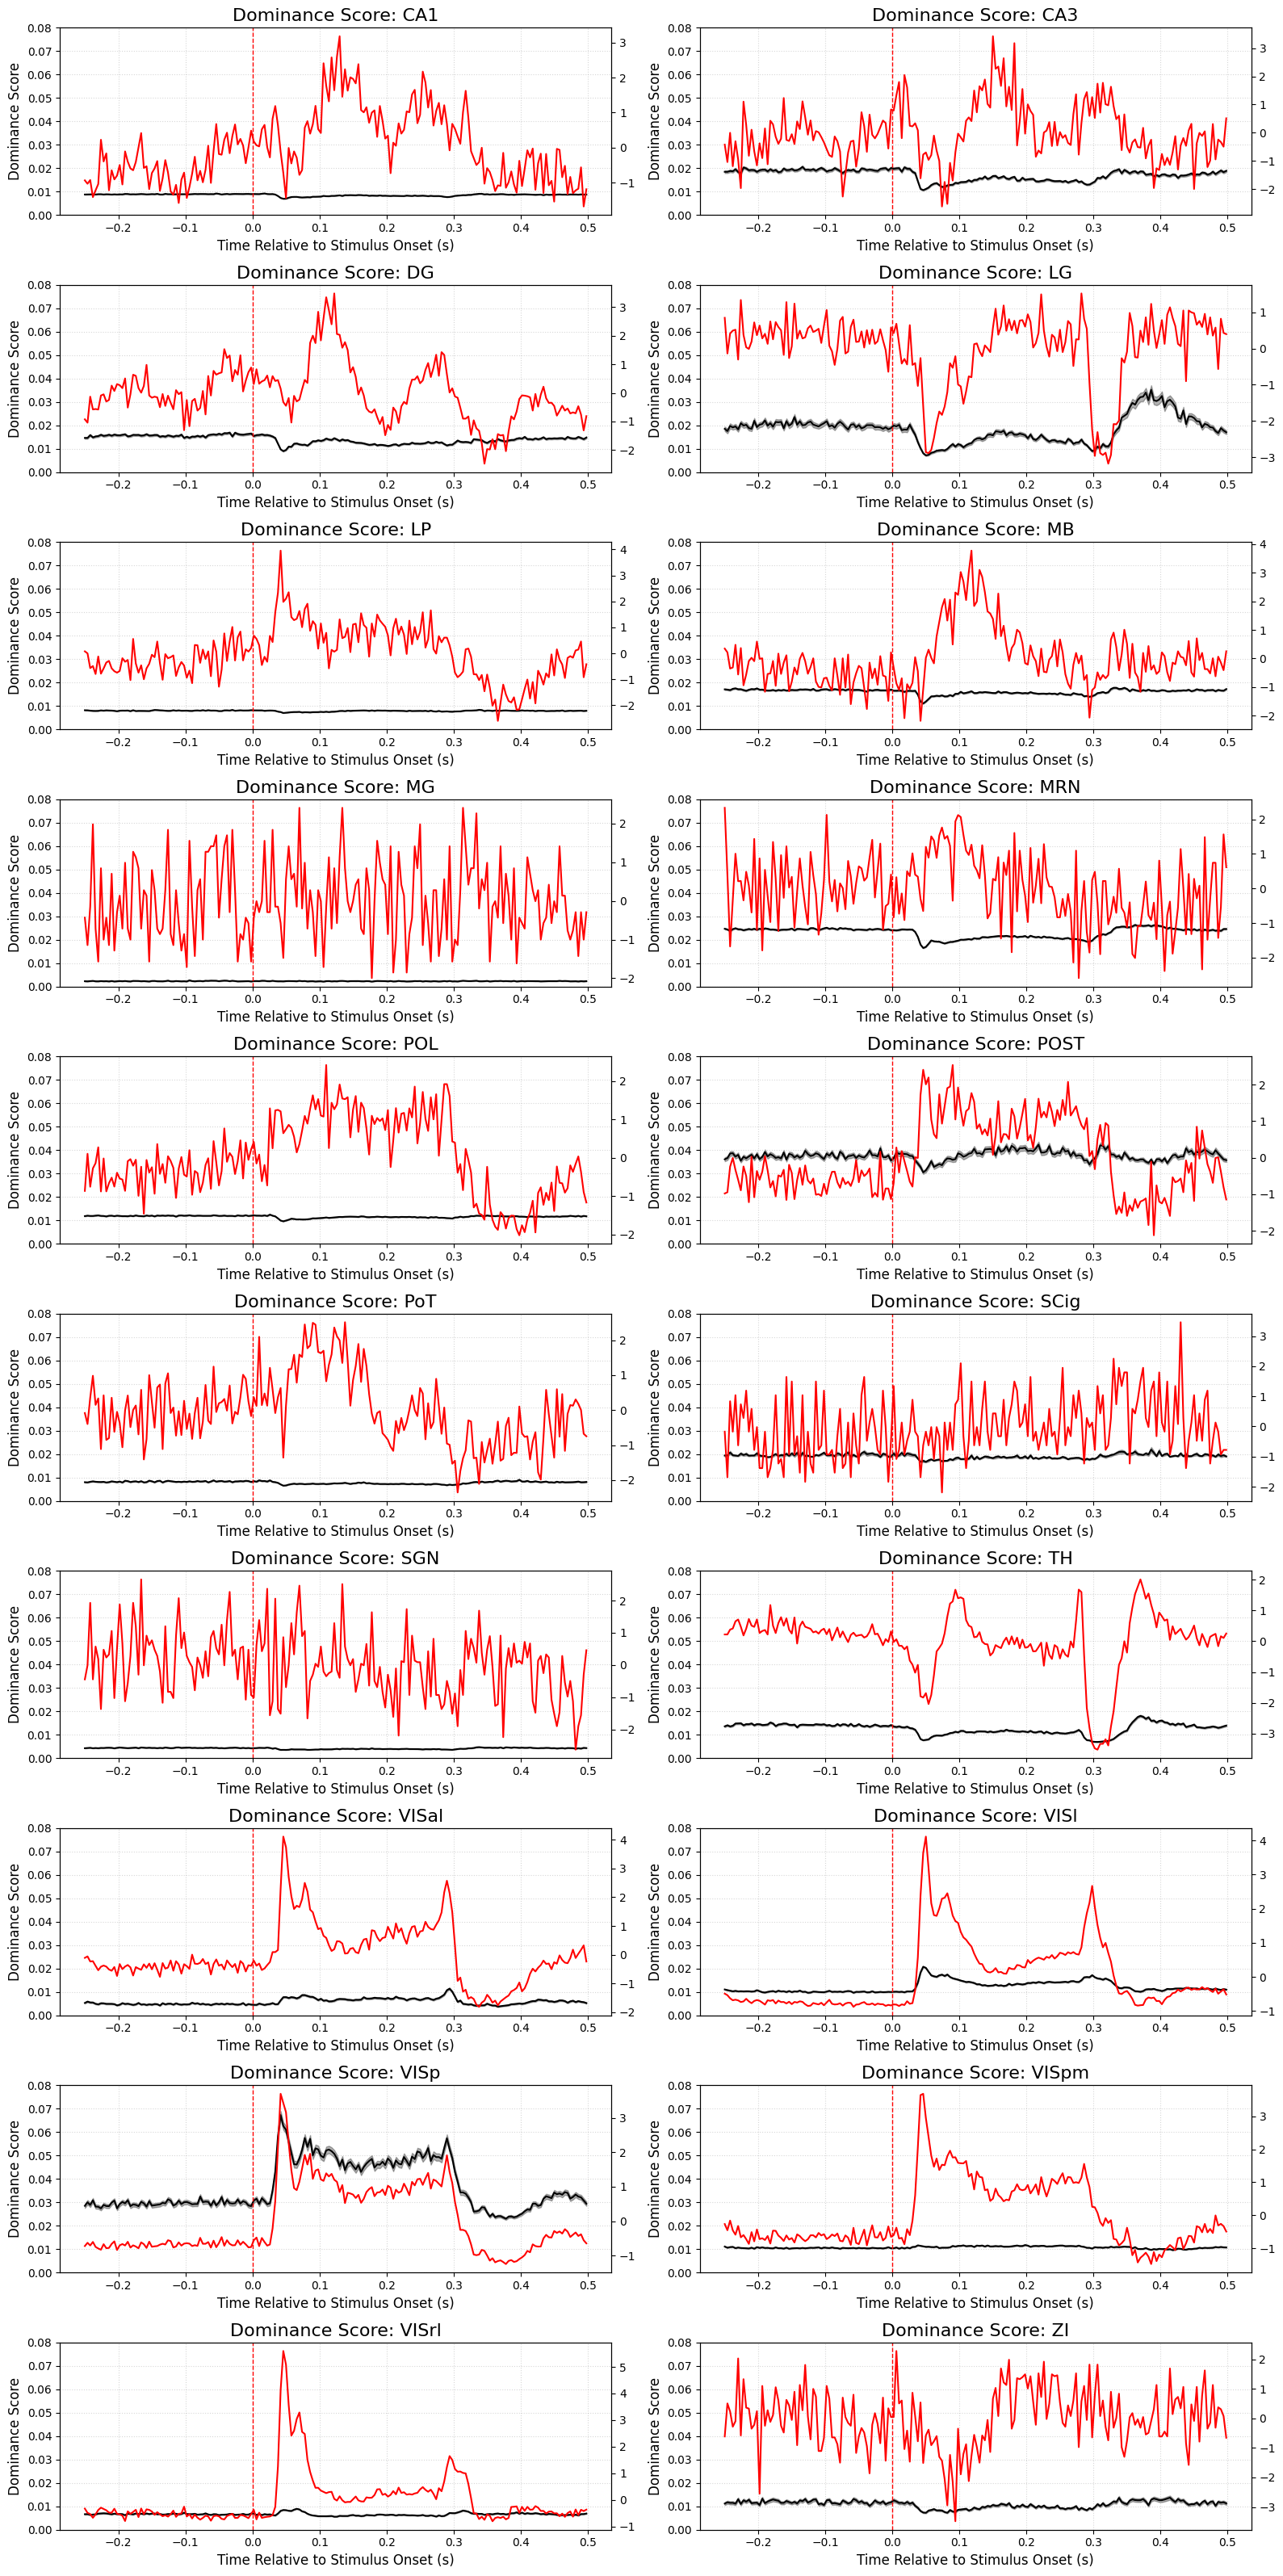

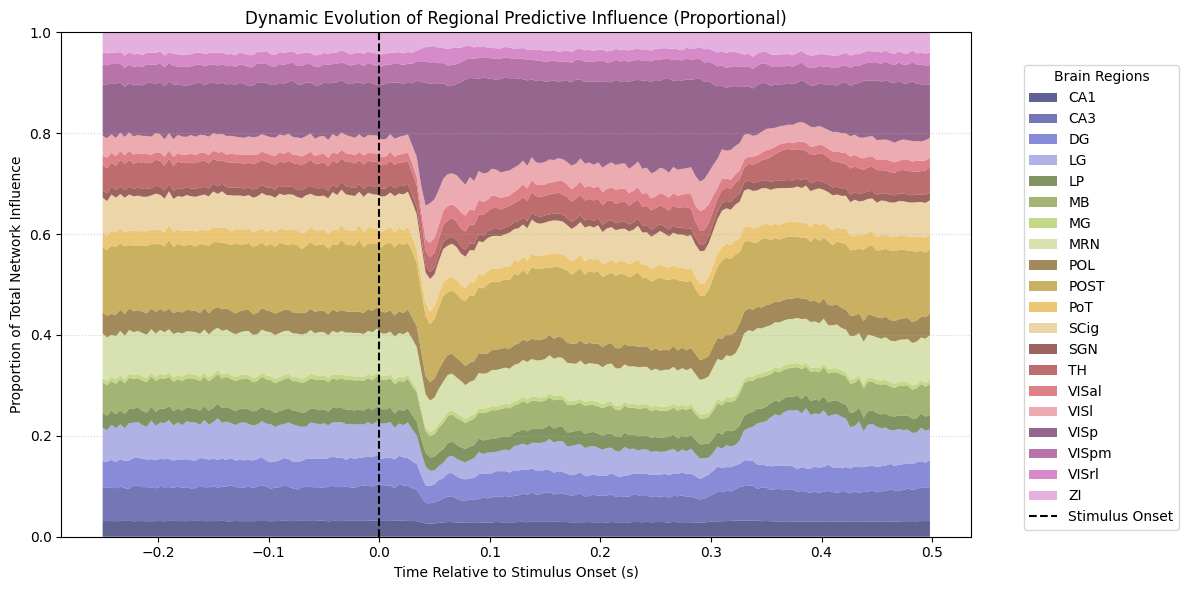

In [622]:
import matplotlib.cm as cm

fig, ax = plt.subplots(int(np.ceil(len(areas)/2)) ,2,figsize=(16,32))
for areai in range(len(areas)):
    ax.flat[areai].plot(t, average_dominance_scores[areai,:], 'k')
    ax.flat[areai].fill_between(t, 
                            average_dominance_scores[areai,:] - err_dominance_scores[areai,:], 
                            average_dominance_scores[areai,:] + err_dominance_scores[areai,:], 
                            color='k', 
                            alpha=0.3,
                            label='SEM')
    # add the psth of that area on a twin ax
    ax2 = ax.flat[areai].twinx()
    ax2.plot(t, zscore(np.mean(psth[locs == areas[areai],:], axis=0)), 'r')
    
    ax.flat[areai].axvline(0, color='r', linestyle='--', linewidth=1)
    ax.flat[areai].set_title(f'Dominance Score: {region_names[areai]}', fontsize=16)
    ax.flat[areai].set_xlabel('Time Relative to Stimulus Onset (s)', fontsize=12)
    ax.flat[areai].set_ylabel('Dominance Score', fontsize=12)
    ax.flat[areai].grid(True, linestyle=':', alpha=0.5)
    ax.flat[areai].set_ylim(0, 0.08)
    
plt.tight_layout()
plt.show()

colors = cm.get_cmap('tab20b', N_regions)(np.arange(N_regions))

fig, ax = plt.subplots(figsize=(12, 6))
# Use Matplotlib's 'stackplot' for the stacked area chart
ax.stackplot(t, proportional_influence, 
             labels=region_names,
             colors=colors, # Apply the generated distinct colors
             alpha=0.8)

# Add stimulus onset
ax.axvline(0, color='k', linestyle='--', linewidth=1.5, label='Stimulus Onset')

# Add Labels and Title
ax.set_title('Dynamic Evolution of Regional Predictive Influence (Proportional)')
ax.set_xlabel('Time Relative to Stimulus Onset (s)')
ax.set_ylabel('Proportion of Total Network Influence')
ax.set_ylim(0, 1) # Proportions must sum to 1
ax.legend(loc='lower left', bbox_to_anchor=(1.05, 0), title='Brain Regions')
ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## Cluster-Based Dominance Score

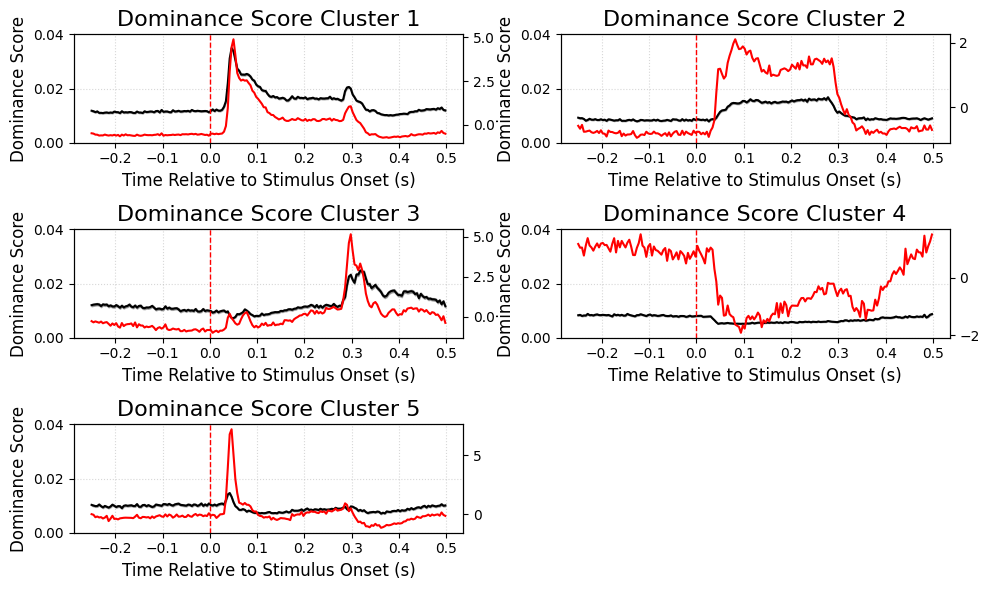

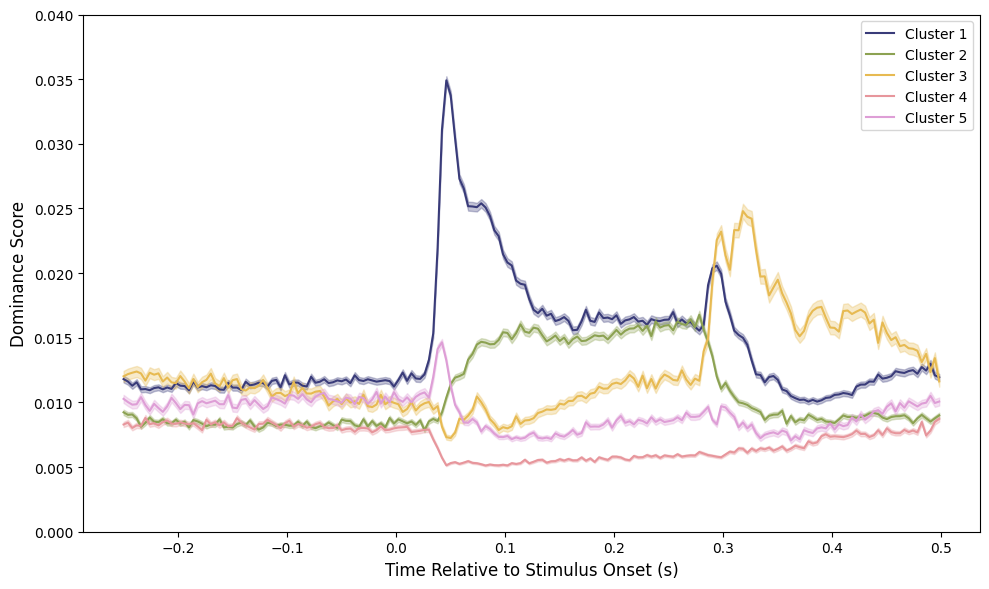

In [625]:
dominance_scores_clusters_3D = np.zeros((N_trials, 5, N_bins_in_snippet))

# Iterate through each stimulus trial
for i in range(N_trials):
    # 1. Determine the start index in the full InverseRank matrix
    start_time_sec = stim_st[i] + time_win[0]
    start_idx = np.argmin(np.abs(timestamps - start_time_sec))
    
    # 2. Extract the snippet (2D array: N_bins_in_snippet x N_neurons)
    snippet = InverseRank_Matrix[start_idx : start_idx + N_bins_in_snippet, :]
    
    # 3. Calculate Dominance Score for each region in the snippet
    for clusteri in range(1,6):
        mask = session_obj.units.index.isin(cluster_id[clusteri])
        
        # NumPy magic: Sum the Inverse Ranks only for neurons where the mask is True.
        # This gives a 1D array of scores (one score per time bin in the snippet).
        dominance_score_time_series = np.sum(snippet[:, mask], axis=1) / np.sum(mask)
        
        # 4. Store the result in the 3D array
        dominance_scores_clusters_3D[i, clusteri-1, :] = dominance_score_time_series
        

average_dominance_scores_clusters = np.mean(dominance_scores_clusters_3D, axis=0) 
err_dominance_scores_clusters     = np.std(dominance_scores_clusters_3D, axis=0) / np.sqrt(N_trials)

total_influence_time_series_clusters = np.sum(average_dominance_scores_clusters, axis=0)

# Reshape total_influence_time_series for broadcasting: (1, N_bins_in_snippet)
total_influence_clusters_reshaped = total_influence_time_series_clusters[np.newaxis, :]

# 2. Calculate Proportional Influence
# This divides the mean score of EACH area by the total mean score across all areas at that time bin.
# Shape: (N_regions, N_bins_in_snippet)
proportional_influence_clusters = average_dominance_scores_clusters / total_influence_clusters_reshaped

# Handle division by zero where total influence is zero (set proportion to zero)
proportional_influence_clusters = np.nan_to_num(proportional_influence_clusters, nan=0.0)

fig, ax = plt.subplots(3 ,2,figsize=(10,6))
for clusteri in range(5):
    ax.flat[clusteri].plot(t, average_dominance_scores_clusters[clusteri,:], 'k')
    ax.flat[clusteri].fill_between(t, 
                            average_dominance_scores_clusters[clusteri,:] - err_dominance_scores_clusters[clusteri,:], 
                            average_dominance_scores_clusters[clusteri,:] + err_dominance_scores_clusters[clusteri,:], 
                            color='k', 
                            alpha=0.3,
                            label='SEM')
    # add the psth of that area on a twin ax
    ax2 = ax.flat[clusteri].twinx()
    mask = session_obj.units.index.isin(cluster_id[clusteri+1])
    ax2.plot(t, zscore(np.mean(psth[mask,:], axis=0)), 'r')
    
    ax.flat[clusteri].axvline(0, color='r', linestyle='--', linewidth=1)
    ax.flat[clusteri].set_title(f'Dominance Score Cluster {clusteri+1}', fontsize=16)
    ax.flat[clusteri].set_xlabel('Time Relative to Stimulus Onset (s)', fontsize=12)
    ax.flat[clusteri].set_ylabel('Dominance Score', fontsize=12)
    ax.flat[clusteri].grid(True, linestyle=':', alpha=0.5)
    ax.flat[clusteri].set_ylim(0, 0.04)

fig.delaxes(ax.flat[-1])    
plt.tight_layout()
plt.show()

colors = cm.get_cmap('tab20b', 5)(np.arange(5))

# all cluisters in one plot
fig, ax = plt.subplots(1 ,1,figsize=(10,6))
for clusteri in range(5):
    ax.plot(t, average_dominance_scores_clusters[clusteri,:], label = f'Cluster {clusteri+1}', color=colors[clusteri,:])
    ax.fill_between(t, 
                        average_dominance_scores_clusters[clusteri,:] - err_dominance_scores_clusters[clusteri,:], 
                        average_dominance_scores_clusters[clusteri,:] + err_dominance_scores_clusters[clusteri,:], 
                        color=colors[clusteri,:], 
                        alpha=0.3)
ax.set_xlabel('Time Relative to Stimulus Onset (s)', fontsize=12)
ax.set_ylabel('Dominance Score', fontsize=12)
ax.set_ylim(0, 0.04)
plt.legend()
plt.tight_layout()
plt.show()

## Baseline-Referenced Stability Analysis

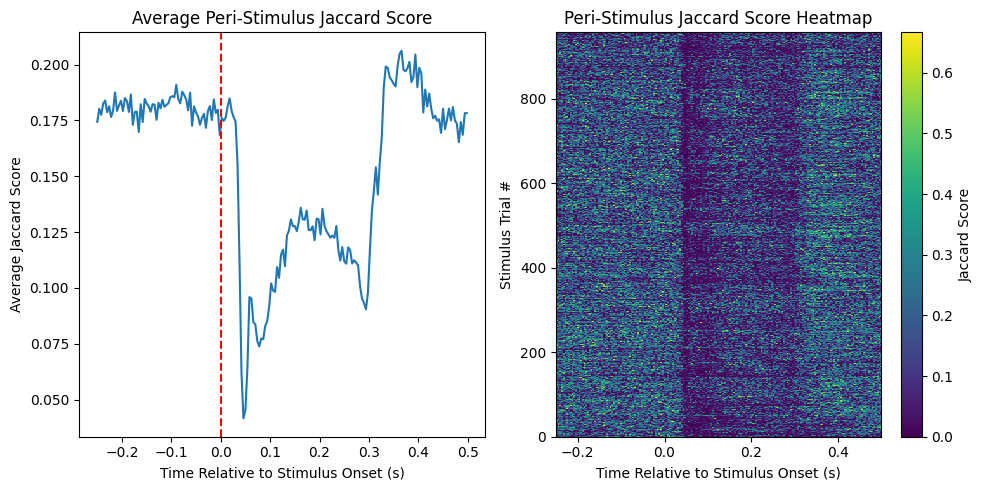

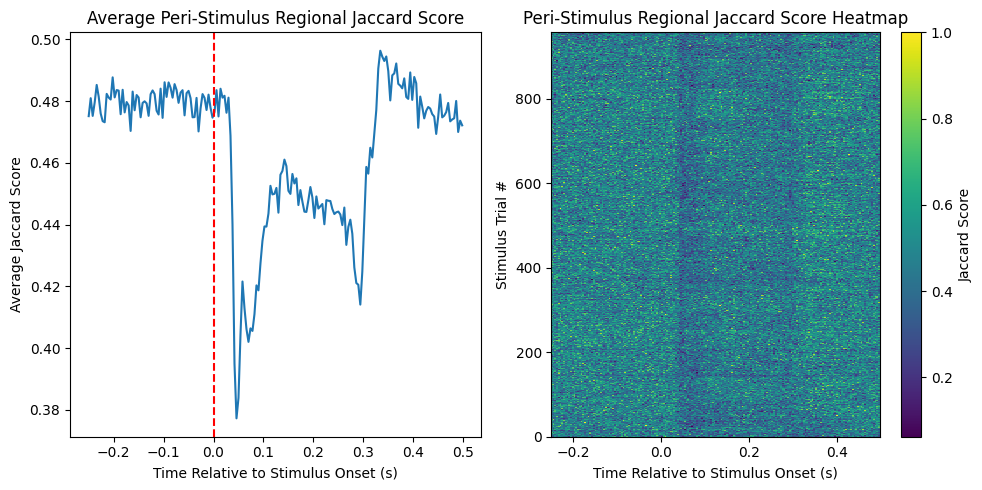

In [626]:
K = 20
baseline_win = [-.25, 0]
baseline_start_idx = np.argmin(np.abs(t - baseline_win[0]))
baseline_end_idx   = np.argmin(np.abs(t - baseline_win[1]))

# compute peri-stimulus rank 
peri_stim_rank = np.zeros((len(stim_st), n_bins_in_snippet,n_neurons))

for i in range(len(stim_st)):
    # Calculate the timestamp (in seconds) corresponding to the start of the snippet window
    start_time_sec = stim_st[i] + time_win[0]
    
    # Find the index in the global timestamps array closest to the start time
    start_idx = np.argmin(np.abs(timestamps - start_time_sec))
    
    # ASSIGN the snippet to the current row (i)
    # The snippet runs from start_idx for a duration of n_bins_in_snippet
    peri_stim_rank[i,:,:] = rank_matrix[start_idx : start_idx + n_bins_in_snippet]

baseline_ranks = peri_stim_rank[:,baseline_start_idx:baseline_end_idx, :]
avg_rank_per_neuron = np.mean(np.mean(baseline_ranks, axis=0), axis=0)

baseline_top_K_indices = np.argsort(avg_rank_per_neuron)[:K]

S_Baseline = set(baseline_top_K_indices)
C_Baseline_regions = set(locs[baseline_top_K_indices])

jaccard_scores_baseline_ref          = np.zeros(n_timepoints)
jaccard_scores_baseline_ref_regional = np.zeros(n_timepoints)

for t_idx in range(n_timepoints):
    # A. Get the instantaneous influential set S_t
    # Find indices where the rank is Top K (rank_matrix <= K)
    indices_t = np.where(rank_matrix[t_idx, :] <= K)[0]
    regions_t_array = locs[indices_t]   
    
    S_t = set(indices_t)
    C_t = set(regions_t_array)
    # B. Calculate Intersection and Union
    intersection = len(S_t.intersection(S_Baseline))
    union = len(S_t.union(S_Baseline))
   
    intersection_regions = len(C_t.intersection(C_Baseline_regions))
    union_regions = len(C_t.union(C_Baseline_regions))    
    
    # C. Calculate Jaccard Similarity (Intersection / Union)
    if union > 0:
        jaccard_scores_baseline_ref[t_idx] = intersection / union
    else:
        jaccard_scores_baseline_ref[t_idx] = 0
        
    if union_regions > 0:
        jaccard_scores_baseline_ref_regional[t_idx] = intersection_regions / union_regions
    else:
        jaccard_scores_baseline_ref_regional[t_idx] = 0     

# --- 4. Visualization ---

jaccard_ref_snippets         = np.zeros((len(stim_st), n_bins_in_snippet))
jaccard_snippets_ref_regions = np.zeros((len(stim_st), n_bins_in_snippet))

for i in range(len(stim_st)):
    # Calculate the timestamp (in seconds) corresponding to the start of the snippet window
    start_time_sec = stim_st[i] + time_win[0]
    
    # Find the index in the global timestamps array closest to the start time
    start_idx = np.argmin(np.abs(timestamps - start_time_sec))
    
    # ASSIGN the snippet to the current row (i)
    # The snippet runs from start_idx for a duration of n_bins_in_snippet
    jaccard_ref_snippets[i, :]         = jaccard_scores_baseline_ref[start_idx : start_idx + n_bins_in_snippet]
    jaccard_snippets_ref_regions[i, :] = jaccard_scores_baseline_ref_regional[start_idx : start_idx + n_bins_in_snippet]


fig, ax = plt.subplots(1,2,figsize=(10,5))

# Plot the Average Time Course
ax[0].plot(t, np.mean(jaccard_ref_snippets, axis=0))
ax[0].set_title('Average Peri-Stimulus Jaccard Score')
ax[0].set_xlabel('Time Relative to Stimulus Onset (s)')
ax[0].set_ylabel('Average Jaccard Score')
ax[0].axvline(0, color='r', linestyle='--')

# Plot the Heatmap
im = ax[1].imshow(jaccard_ref_snippets, aspect='auto', cmap='viridis', 
           extent=[t[0], t[-1], len(stim_st), 0], 
           interpolation='none')
ax[1].set_xlabel('Time Relative to Stimulus Onset (s)')
ax[1].set_ylabel('Stimulus Trial #')
ax[1].set_title('Peri-Stimulus Jaccard Score Heatmap')
cbar = plt.colorbar(mappable=im, ax=ax[1])
cbar.set_label('Jaccard Score')
ax[1].invert_yaxis()  # Invert y-axis so trial 1 is at the top
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1,2,figsize=(10,5))

# Plot the Average Time Course
ax[0].plot(t, np.mean(jaccard_snippets_ref_regions, axis=0))
ax[0].set_title('Average Peri-Stimulus Regional Jaccard Score')
ax[0].set_xlabel('Time Relative to Stimulus Onset (s)')
ax[0].set_ylabel('Average Jaccard Score')
ax[0].axvline(0, color='r', linestyle='--')

# Plot the Heatmap
im = ax[1].imshow(jaccard_snippets_ref_regions, aspect='auto', cmap='viridis', 
           extent=[t[0], t[-1], len(stim_st), 0], 
           interpolation='none')
ax[1].set_xlabel('Time Relative to Stimulus Onset (s)')
ax[1].set_ylabel('Stimulus Trial #')
ax[1].set_title('Peri-Stimulus Regional Jaccard Score Heatmap')
cbar = plt.colorbar(mappable=im, ax=ax[1])
cbar.set_label('Jaccard Score')
ax[1].invert_yaxis()  # Invert y-axis so trial 1 is at the top
plt.tight_layout()
plt.show()